### **1. Loading raw dataset**

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_RAW = ROOT / "data_raw"
DATA_PROCESSED = ROOT / "data_processed"

csv_path = DATA_RAW / "dka_site13_raw.csv"

print("Project root:", ROOT)
print("CSV exists:", csv_path.exists())
print("CSV size MB:", round(csv_path.stat().st_size / (1024**2), 2))

Project root: e:\D\Research Work FAST Thesis\pv-thesis
CSV exists: True
CSV size MB: 282.7


In [2]:
# Read only first few rows first. Do not load everything yet.
sample = pd.read_csv(csv_path, nrows=10)
print(sample.shape)
print(sample.columns.tolist())
display(sample)

(10, 14)
['timestamp', 'Active_Energy_Delivered_Received', 'Current_Phase_Average', 'Active_Power', 'Performance_Ratio', 'Wind_Speed', 'Weather_Temperature_Celsius', 'Weather_Relative_Humidity', 'Global_Horizontal_Radiation', 'Diffuse_Horizontal_Radiation', 'Wind_Direction', 'Weather_Daily_Rainfall', 'Radiation_Global_Tilted', 'Radiation_Diffuse_Tilted']


,timestamp,Active_Energy_Delivered_Received,Current_Phase_Average,Active_Power,Performance_Ratio,Wind_Speed,Weather_Temperature_Celsius,Weather_Relative_Humidity,Global_Horizontal_Radiation,Diffuse_Horizontal_Radiation,Wind_Direction,Weather_Daily_Rainfall,Radiation_Global_Tilted,Radiation_Diffuse_Tilted
0,2008-09-12 05:55:00,0,0,0,NaN,NaN,25.734350,18.551216,5.227983,2.215820,103.423134,0,NaN,NaN
1,2008-09-12 06:00:00,0,0,0,NaN,NaN,25.402353,19.242727,5.408280,2.435364,125.776703,0,NaN,NaN
2,2008-09-12 06:05:00,0,0,0,NaN,NaN,25.141418,19.368038,4.931451,1.885518,163.055115,0,NaN,NaN
3,2008-09-12 06:10:00,0,0,0,NaN,NaN,25.015263,19.301992,4.298166,1.327833,137.553268,0,NaN,NaN
4,2008-09-12 06:15:00,0,0,0,NaN,NaN,24.935015,19.123230,4.499399,1.520790,128.099182,0,NaN,NaN
5,2008-09-12 06:20:00,0,0,0,NaN,NaN,24.771814,19.220928,4.727537,1.694162,166.943619,0,NaN,NaN
6,2008-09-12 06:25:00,0,0,0,NaN,NaN,24.339149,19.900251,4.893287,1.933765,151.212036,0,NaN,NaN
7,2008-09-12 06:30:00,0,0,0,NaN,NaN,23.965853,20.330284,5.030112,2.044551,203.000046,0,NaN,NaN
8,2008-09-12 06:35:00,0,0,0,NaN,NaN,23.899315,19.967632,4.774568,1.762097,184.896255,0,NaN,NaN
9,2008-09-12 06:40:00,0,0,0,NaN,NaN,23.842218,20.147463,4.918225,1.833571,149.436081,0,NaN,NaN


In [3]:
# Count rows without loading the whole file into memory.
with open(csv_path, "rb") as f:
    total_lines = sum(1 for _ in f)

print("Total data rows:", total_lines - 1)

Total data rows: 1767911


In [5]:
# Load full dataset
df = pd.read_csv(
    csv_path,
    parse_dates=["timestamp"],
    low_memory=False
)

df.columns = df.columns.str.strip()

print(df.shape)

(1767911, 14)


In [6]:
print(df["timestamp"].min(), "to", df["timestamp"].max())

2008-09-12 05:55:00 to 2025-08-23 05:55:00


In [7]:
display(df.head())

,timestamp,Active_Energy_Delivered_Received,Current_Phase_Average,Active_Power,Performance_Ratio,Wind_Speed,Weather_Temperature_Celsius,Weather_Relative_Humidity,Global_Horizontal_Radiation,Diffuse_Horizontal_Radiation,Wind_Direction,Weather_Daily_Rainfall,Radiation_Global_Tilted,Radiation_Diffuse_Tilted
0,2008-09-12 05:55:00,0.0,0.0,0.0,NaN,NaN,25.734350,18.551216,5.227983,2.215820,103.423134,0.0,NaN,NaN
1,2008-09-12 06:00:00,0.0,0.0,0.0,NaN,NaN,25.402353,19.242727,5.408280,2.435364,125.776703,0.0,NaN,NaN
2,2008-09-12 06:05:00,0.0,0.0,0.0,NaN,NaN,25.141418,19.368038,4.931451,1.885518,163.055115,0.0,NaN,NaN
3,2008-09-12 06:10:00,0.0,0.0,0.0,NaN,NaN,25.015263,19.301992,4.298166,1.327833,137.553268,0.0,NaN,NaN
4,2008-09-12 06:15:00,0.0,0.0,0.0,NaN,NaN,24.935015,19.123230,4.499399,1.520790,128.099182,0.0,NaN,NaN


In [8]:
display(df.tail())

,timestamp,Active_Energy_Delivered_Received,Current_Phase_Average,Active_Power,Performance_Ratio,Wind_Speed,Weather_Temperature_Celsius,Weather_Relative_Humidity,Global_Horizontal_Radiation,Diffuse_Horizontal_Radiation,Wind_Direction,Weather_Daily_Rainfall,Radiation_Global_Tilted,Radiation_Diffuse_Tilted
1767906,2025-08-23 05:35:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.502842,0.765323
1767907,2025-08-23 05:40:00,159912.0,0.3,0.0,0.0,NaN,6.514468,48.271492,1.875676,1.182508,34.249779,0.0,4.420346,0.746060
1767908,2025-08-23 05:45:00,159912.0,0.3,0.0,0.0,NaN,6.181243,49.345993,2.335162,1.723683,34.252014,0.0,4.374092,0.740311
1767909,2025-08-23 05:50:00,159912.0,0.3,0.0,0.0,NaN,6.100413,50.220795,1.981858,1.283030,34.250034,0.0,4.347583,0.637820
1767910,2025-08-23 05:55:00,159912.0,0.3,0.0,0.0,NaN,6.091383,50.647717,1.681748,1.132713,34.258087,0.0,4.477606,0.935539


### **2. EDA**

In [ ]:
#Create clean raw dataframe reference

df_raw = df.copy()

In [35]:
df_raw["is_power_zero"] = df_raw["Active_Power"].eq(0)

df_raw["is_daylight_like"] = df_raw["Global_Horizontal_Radiation"].fillna(0) > 20

df_raw["suspicious_daytime_zero"] = (
    df_raw["is_daylight_like"] &
    df_raw["is_power_zero"]
)

print("Total rows:", len(df_raw))
print("Power zero rows:", df_raw["is_power_zero"].sum())
print("Suspicious daytime zero rows:", df_raw["suspicious_daytime_zero"].sum())

Total rows: 1767911
Power zero rows: 883335
Suspicious daytime zero rows: 6420


In [37]:
df_raw = df_raw.sort_values("timestamp").reset_index(drop=True)
print("Timestamp range:", df_raw["timestamp"].min(), "to", df_raw["timestamp"].max())

Timestamp range: 2008-09-12 05:55:00 to 2025-08-23 05:55:00


In [38]:
df_raw.shape

(1767911, 17)

In [39]:
df_raw.head()

,timestamp,Active_Energy_Delivered_Received,Current_Phase_Average,Active_Power,Performance_Ratio,Wind_Speed,Weather_Temperature_Celsius,Weather_Relative_Humidity,Global_Horizontal_Radiation,Diffuse_Horizontal_Radiation,Wind_Direction,Weather_Daily_Rainfall,Radiation_Global_Tilted,Radiation_Diffuse_Tilted,is_power_zero,is_daylight_like,suspicious_daytime_zero
0,2008-09-12 05:55:00,0.0,0.0,0.0,NaN,NaN,25.734350,18.551216,5.227983,2.215820,103.423134,0.0,NaN,NaN,True,False,False
1,2008-09-12 06:00:00,0.0,0.0,0.0,NaN,NaN,25.402353,19.242727,5.408280,2.435364,125.776703,0.0,NaN,NaN,True,False,False
2,2008-09-12 06:05:00,0.0,0.0,0.0,NaN,NaN,25.141418,19.368038,4.931451,1.885518,163.055115,0.0,NaN,NaN,True,False,False
3,2008-09-12 06:10:00,0.0,0.0,0.0,NaN,NaN,25.015263,19.301992,4.298166,1.327833,137.553268,0.0,NaN,NaN,True,False,False
4,2008-09-12 06:15:00,0.0,0.0,0.0,NaN,NaN,24.935015,19.123230,4.499399,1.520790,128.099182,0.0,NaN,NaN,True,False,False


In [ ]:
#Checkpoint helper functions

from datetime import datetime

CHECKPOINT_DIR = DATA_PROCESSED / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

checkpoint_log_path = CHECKPOINT_DIR / "checkpoint_log.csv"


def save_checkpoint(dataframe, name, note):
    """
    Saves a dataframe checkpoint to disk and records a short note.
    Uses parquet if available, otherwise falls back to pickle.
    """
    timestamp_now = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    
    try:
        file_path = CHECKPOINT_DIR / f"{name}.parquet"
        dataframe.to_parquet(file_path, index=False)
        file_type = "parquet"
    except Exception as e:
        file_path = CHECKPOINT_DIR / f"{name}.pkl"
        dataframe.to_pickle(file_path)
        file_type = "pickle"
        print("Parquet save failed, saved as pickle instead.")
        print("Reason:", e)

    log_row = pd.DataFrame([{
        "checkpoint_name": name,
        "file_path": str(file_path),
        "file_type": file_type,
        "rows": len(dataframe),
        "columns": dataframe.shape[1],
        "created_at": timestamp_now,
        "note": note
    }])

    if checkpoint_log_path.exists():
        old_log = pd.read_csv(checkpoint_log_path)
        new_log = pd.concat([old_log, log_row], ignore_index=True)
    else:
        new_log = log_row

    new_log.to_csv(checkpoint_log_path, index=False)

    print(f"Saved checkpoint: {name}")
    print(f"Path: {file_path}")


def load_checkpoint(name):
    """
    Restores a checkpoint by name.
    """
    parquet_path = CHECKPOINT_DIR / f"{name}.parquet"
    pickle_path = CHECKPOINT_DIR / f"{name}.pkl"

    if parquet_path.exists():
        return pd.read_parquet(parquet_path)
    elif pickle_path.exists():
        return pd.read_pickle(pickle_path)
    else:
        raise FileNotFoundError(f"No checkpoint found with name: {name}")

In [ ]:
#Optional raw-loaded checkpoint

save_checkpoint(
    df_raw,
    name="00_raw_loaded",
    note="Raw Site 13 dataset loaded from CSV, sorted by timestamp, no cleaning applied."
)

Parquet save failed, saved as pickle instead.
Reason: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - `Import pyarrow` failed. pyarrow is required for parquet support. Use pip or conda to install the pyarrow package.
 - `Import fastparquet` failed. fastparquet is required for parquet support. Use pip or conda to install the fastparquet package.
Saved checkpoint: 00_raw_loaded
Path: e:\D\Research Work FAST Thesis\pv-thesis\data_processed\checkpoints\00_raw_loaded.pkl


In [ ]:
#Column types and missing summary

summary = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "missing_count": df_raw.isna().sum(),
    "missing_pct": (df_raw.isna().sum() / len(df_raw) * 100).round(3),
    "unique_count": df_raw.nunique(dropna=True)
})

display(summary)

,dtype,missing_count,missing_pct,unique_count
timestamp,datetime64[us],0,0.000,1767911
Active_Energy_Delivered_Received,float64,31368,1.774,158901
Current_Phase_Average,float64,31313,1.771,225653
Active_Power,float64,31313,1.771,376584
Performance_Ratio,float64,735640,41.611,485824
Wind_Speed,float64,926140,52.386,708077
Weather_Temperature_Celsius,float64,41754,2.362,1643796
Weather_Relative_Humidity,float64,41745,2.361,1668112
Global_Horizontal_Radiation,float64,41705,2.359,1688001
Diffuse_Horizontal_Radiation,float64,41705,2.359,1690094


In [82]:
#Yearly data coverage overview

yearly = df_raw.groupby(df_raw['timestamp'].dt.year).agg(
    total_rows    = ('Active_Power', 'count'),
    missing_power = ('Active_Power', lambda x: x.isnull().sum()),
    all_rows      = ('Active_Power', 'size'),
).assign(
    coverage_pct = lambda d: (d['total_rows'] / d['all_rows'] * 100).round(1)
)

yearly.index.name = 'Year'
print(yearly.to_string())

      total_rows  missing_power  all_rows  coverage_pct
Year                                                   
2008       31383            375     31758          98.8
2009      105115              1    105116         100.0
2010      105120              0    105120         100.0
2011      104901              0    104901         100.0
2012      104909            485    105394          99.5
2013      105050             26    105076         100.0
2014      105111              0    105111         100.0
2015      105120              0    105120         100.0
2016      105408              0    105408         100.0
2017      104513            101    104614          99.9
2018      105120              0    105120         100.0
2019      102905              0    102905         100.0
2020      105379              2    105381         100.0
2021      100535              4    100539         100.0
2022      102890             11    102901         100.0
2023       97759           4038    101797       

In [84]:
#Wind_Speed availability by year

wind_by_year = df_raw.groupby(df_raw['timestamp'].dt.year)['Wind_Speed'].apply(
    lambda x: round((x.notna().sum() / len(x)) * 100, 1)
).rename('Wind_Speed_Coverage_%')

print("Wind_Speed availability by year:")
print(wind_by_year.to_string())

Wind_Speed availability by year:
timestamp
2008     76.6
2009    100.0
2010    100.0
2011     99.5
2012     99.0
2013     98.4
2014    100.0
2015    100.0
2016     80.5
2017      0.0
2018      0.0
2019      0.0
2020      0.0
2021      0.0
2022      0.0
2023      0.0
2024      0.0
2025      0.0


In [51]:
#Numeric value ranges

numeric_cols = df_raw.select_dtypes(include=["number"]).columns.tolist()

range_summary = df_raw[numeric_cols].describe(
    percentiles=[0.001, 0.01, 0.05, 0.5, 0.95, 0.99, 0.999]
).T

display(range_summary)

,count,mean,std,min,0.1%,1%,5%,50%,95%,99%,99.9%,max
Active_Energy_Delivered_Received,1736543.0,79270.641177,46115.507746,0.000000,0.000000,25.000000,6703.100000,79061.000000,151518.000000,158310.000000,159745.000000,159912.000000
Current_Phase_Average,1736598.0,4.662943,6.072643,0.000000,0.000000,0.300000,0.300000,0.300000,16.600004,17.829330,19.092468,23.666000
Active_Power,1736598.0,1.077654,1.523068,-0.040000,-0.004600,0.000000,0.000000,0.000000,4.062600,4.394867,4.734866,5.824800
Performance_Ratio,1032271.0,197.168731,2663.684620,-42.780548,-2.273351,0.000000,0.000000,0.000000,85.896687,501.534540,38649.187812,122225.914062
Wind_Speed,841771.0,2.508527,4.362972,-1742.130707,0.000000,0.000000,0.578550,2.251974,5.485398,7.778006,10.278008,54.389500
Weather_Temperature_Celsius,1726157.0,21.154364,9.887404,-39.987949,-38.843342,0.000000,4.422272,21.684725,36.461304,39.979098,42.799325,61.923546
Weather_Relative_Humidity,1726166.0,38.805623,24.390027,0.000000,0.000000,6.061221,9.671623,32.029831,87.896700,99.534351,101.904669,131.158401
Global_Horizontal_Radiation,1726206.0,261.858123,360.252987,-985.690002,0.000000,0.606819,1.326911,8.108581,1017.674347,1153.960516,1240.708682,2725.605957
Diffuse_Horizontal_Radiation,1726206.0,55.169169,91.114617,0.000000,0.000000,0.383324,0.575174,6.122670,251.043137,446.814680,603.548187,2134.985107
Wind_Direction,1724048.0,25.189012,2894.469950,-99999.914062,-6449.323943,0.605732,10.708256,81.840618,311.021919,345.575775,357.000000,30152.339844


**Timestamp Integrity Checks**

In [57]:
#Timestamp integrity check

ts = df_raw["timestamp"]

print("Timestamp missing values:", ts.isna().sum())
print("Is timestamp sorted?", ts.is_monotonic_increasing)
print("Duplicate timestamps:", ts.duplicated().sum())

if ts.duplicated().sum() > 0:
    duplicate_rows = df_raw.loc[ts.duplicated(keep=False)].sort_values("timestamp")
    display(duplicate_rows.head(20))

Timestamp missing values: 0
Is timestamp sorted? True
Duplicate timestamps: 0


In [58]:
#Check actual time-step frequency

ts_sorted = df_raw["timestamp"].sort_values()
time_deltas = ts_sorted.diff()

delta_counts = time_deltas.value_counts().head(10).reset_index()
delta_counts.columns = ["time_step", "count"]

display(delta_counts)

,time_step,count
0,0 days 00:05:00,1767567
1,0 days 00:10:00,244
2,0 days 00:15:00,30
3,0 days 00:20:00,16
4,0 days 00:25:00,12
5,0 days 01:30:00,4
6,0 days 01:10:00,3
7,0 days 00:40:00,3
8,0 days 00:30:00,3
9,0 days 00:35:00,2


In [59]:
#Identify timestamp gaps

expected_step = pd.Timedelta(minutes=5)

gap_mask = time_deltas > expected_step

gaps = pd.DataFrame({
    "gap_start": ts_sorted.shift().loc[gap_mask].values,
    "gap_end": ts_sorted.loc[gap_mask].values,
    "gap_duration": time_deltas.loc[gap_mask].values
})

if len(gaps) > 0:
    gaps["missing_5min_rows_estimate"] = (
        gaps["gap_duration"] / expected_step - 1
    ).astype(int)

    gaps = gaps.sort_values("gap_duration", ascending=False).reset_index(drop=True)

print("Number of timestamp gaps:", len(gaps))
display(gaps.head(20))

Number of timestamp gaps: 343


,gap_start,gap_end,gap_duration,missing_5min_rows_estimate
0,2021-01-27 14:05:00,2021-02-10 14:25:00,14 days 00:20:00,4035
1,2019-11-12 12:00:00,2019-11-19 19:20:00,7 days 07:20:00,2103
2,2023-01-24 08:00:00,2023-01-30 13:45:00,6 days 05:45:00,1796
3,2022-01-02 16:15:00,2022-01-07 11:45:00,4 days 19:30:00,1385
4,2023-12-20 11:15:00,2023-12-23 18:45:00,3 days 07:30:00,953
5,2022-04-26 21:00:00,2022-04-29 16:30:00,2 days 19:30:00,809
6,2024-03-08 08:30:00,2024-03-10 14:55:00,2 days 06:25:00,652
7,2021-08-30 16:50:00,2021-09-01 09:45:00,1 days 16:55:00,490
8,2017-07-10 14:40:00,2017-07-12 07:30:00,1 days 16:50:00,489
9,2024-12-11 03:30:00,2024-12-12 10:15:00,1 days 06:45:00,368


In [60]:
#Expected full 5-minute grid check

expected_timestamps = pd.date_range(
    start=df_raw["timestamp"].min(),
    end=df_raw["timestamp"].max(),
    freq="5min"
)

actual_timestamps = pd.DatetimeIndex(df_raw["timestamp"])

missing_timestamps = expected_timestamps.difference(actual_timestamps)

print("Expected timestamps:", len(expected_timestamps))
print("Actual rows:", len(actual_timestamps))
print("Missing timestamps from full 5-min grid:", len(missing_timestamps))

display(pd.Series(missing_timestamps[:20], name="first_missing_timestamps"))

Expected timestamps: 1782433
Actual rows: 1767911
Missing timestamps from full 5-min grid: 14522


0    2008-09-27 11:30:00
1    2008-09-27 11:35:00
2    2008-09-27 11:40:00
3    2008-09-27 11:45:00
4    2008-09-27 11:50:00
5    2008-09-27 11:55:00
6    2008-09-27 12:00:00
7    2008-09-27 12:05:00
8    2008-09-27 12:10:00
9    2008-09-27 12:15:00
10   2008-09-27 12:20:00
11   2008-09-27 12:25:00
12   2008-09-27 12:30:00
13   2008-09-27 12:35:00
14   2008-09-27 12:40:00
15   2008-09-27 12:45:00
16   2008-09-27 12:50:00
17   2008-09-27 12:55:00
18   2008-09-27 13:00:00
19   2008-09-27 13:05:00
Name: first_missing_timestamps, dtype: datetime64[us]

**Missing-value exploration**

In [66]:
#Missing values by year

key_cols = [
    "Active_Power",
    "Current_Phase_Average",
    "Global_Horizontal_Radiation",
    "Diffuse_Horizontal_Radiation",
    "Weather_Temperature_Celsius",
    "Weather_Relative_Humidity",
    "Wind_Speed",
    "Wind_Direction",
    "Weather_Daily_Rainfall",
    "Radiation_Global_Tilted",
    "Radiation_Diffuse_Tilted",
    "Performance_Ratio"
]

key_cols = [c for c in key_cols if c in df_raw.columns]

df_time = df_raw.set_index("timestamp")

missing_by_year = df_time[key_cols].isna().resample("YE").sum()
missing_by_year.index = missing_by_year.index.year

rows_by_year = df_time.resample("YE").size()
rows_by_year.index = rows_by_year.index.year

missing_pct_by_year = missing_by_year.div(rows_by_year, axis=0).mul(100).round(2)

display(missing_by_year)

,Active_Power,Current_Phase_Average,Global_Horizontal_Radiation,Diffuse_Horizontal_Radiation,Weather_Temperature_Celsius,Weather_Relative_Humidity,Wind_Speed,Wind_Direction,Weather_Daily_Rainfall,Radiation_Global_Tilted,Radiation_Diffuse_Tilted,Performance_Ratio
timestamp,,,,,,,,,,,,
2008,375,375,5823,5823,5823,5823,7416,5823,5808,31758,31758,31758
2009,1,1,0,0,0,0,0,0,0,105116,105116,105116
2010,0,0,0,0,0,0,0,0,0,105120,105120,105120
2011,0,0,567,567,567,567,567,567,567,104901,104901,104901
2012,485,485,485,485,485,485,1038,1038,485,105394,105394,105394
2013,26,26,26,26,26,26,1634,1634,22,43915,43915,105076
2014,0,0,0,0,0,0,0,0,0,28573,3046,105111
2015,0,0,0,0,0,0,0,0,0,17042,442,42738
2016,0,0,0,0,0,0,20578,0,0,1380,1380,0


C:\Users\AAC\AppData\Local\Temp\ipykernel_17156\35801300.py:19: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig('../results/active_power_nan_by_month.png', dpi=150)


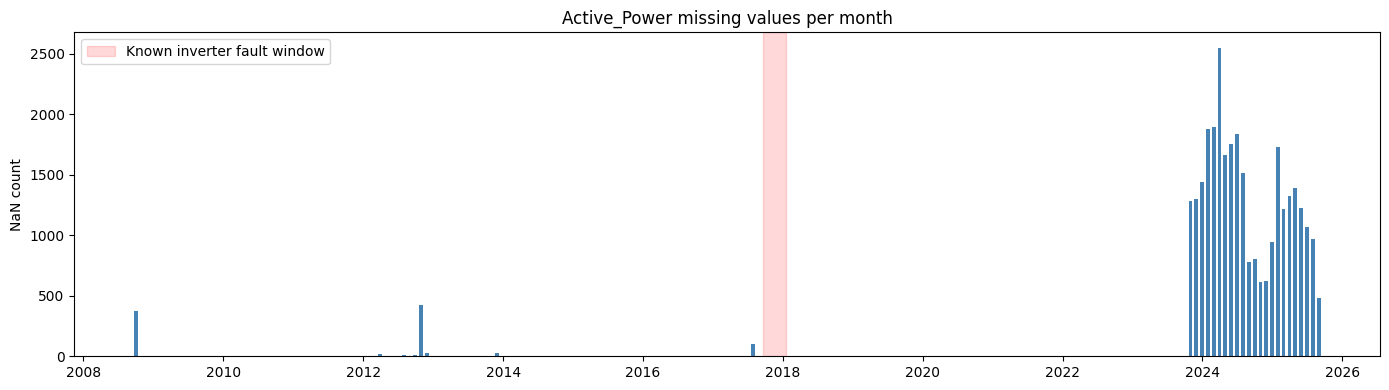

In [85]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Set timestamp as a temporary working series for resampling
ts = df_raw.set_index('timestamp')

power_nan_monthly = ts['Active_Power'].isnull().resample('ME').sum()
power_nan_monthly = power_nan_monthly[power_nan_monthly > 0]

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(power_nan_monthly.index, power_nan_monthly.values, width=20, color='steelblue')
ax.axvspan(pd.Timestamp('2017-09-22'), pd.Timestamp('2018-01-19'),
           color='red', alpha=0.15, label='Known inverter fault window')
ax.set_title('Active_Power missing values per month')
ax.set_ylabel('NaN count')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('../results/active_power_nan_by_month.png', dpi=150)
plt.show()

In [86]:
#Negative Active_Power values

neg_power = df_raw[df_raw['Active_Power'] < 0]
print(f"Negative Active_Power rows: {len(neg_power)}")

if len(neg_power) > 0:
    print(f"\nValue range: {neg_power['Active_Power'].min():.4f} to {neg_power['Active_Power'].max():.4f} kW")
    print(f"\nStats:")
    print(neg_power['Active_Power'].describe())
    print("\nSample rows:")
    display(neg_power[['timestamp', 'Active_Power', 'Global_Horizontal_Radiation']].head(10))

Negative Active_Power rows: 6690

Value range: -0.0400 to -0.0000 kW

Stats:
count    6.690000e+03
mean    -2.942932e-03
std      3.536253e-03
min     -4.000000e-02
25%     -4.766666e-03
50%     -1.333333e-03
75%     -2.000000e-04
max     -3.637900e-12
Name: Active_Power, dtype: float64

Sample rows:


,timestamp,Active_Power,Global_Horizontal_Radiation
4079,2008-09-26 09:50:00,-0.026667,716.304688
4183,2008-09-26 18:30:00,-0.040000,1005.937988
19076,2008-11-17 18:55:00,-0.000067,13.206334
19077,2008-11-17 19:00:00,-0.003133,10.147493
21618,2008-11-26 19:00:00,-0.000167,14.022162
22195,2008-11-28 19:05:00,-0.000067,13.035871
23060,2008-12-01 19:10:00,-0.001200,7.239523
23346,2008-12-02 19:00:00,-0.001567,10.561405
23347,2008-12-02 19:05:00,-0.003500,9.455713
23635,2008-12-03 19:05:00,-0.001067,11.172415


In [67]:
#Missing-value pattern overlap

core_cols = [
    "Active_Power",
    "Global_Horizontal_Radiation",
    "Diffuse_Horizontal_Radiation",
    "Weather_Temperature_Celsius",
    "Weather_Relative_Humidity"
]

core_cols = [c for c in core_cols if c in df_raw.columns]

missing_pattern_counts = (
    df_raw[core_cols]
    .isna()
    .value_counts()
    .reset_index(name="rows")
)

missing_pattern_counts["pct"] = (
    missing_pattern_counts["rows"] / len(df_raw) * 100
).round(3)

display(missing_pattern_counts.head(20))

,Active_Power,Global_Horizontal_Radiation,Diffuse_Horizontal_Radiation,Weather_Temperature_Celsius,Weather_Relative_Humidity,rows,pct
0,False,False,False,False,False,1725297,97.590
1,True,True,True,True,True,30410,1.720
2,False,True,True,True,True,11292,0.639
3,True,False,False,False,False,857,0.048
4,True,False,False,True,True,38,0.002
5,True,False,False,True,False,8,0.000
6,False,False,False,True,True,5,0.000
7,False,True,True,False,False,3,0.000
8,False,False,False,True,False,1,0.000


In [68]:
#Consecutive missing-value runs

def summarize_runs(dataframe, mask, label, max_runs=20):
    """
    Summarizes consecutive True regions in a boolean mask.
    Useful for missing periods, outages, and suspicious zero runs.
    """
    mask = pd.Series(mask, index=dataframe.index).fillna(False)

    temp = pd.DataFrame({
        "timestamp": dataframe["timestamp"],
        "flag": mask
    })

    groups = (temp["flag"] != temp["flag"].shift()).cumsum()

    runs = (
        temp[temp["flag"]]
        .groupby(groups[temp["flag"]])["timestamp"]
        .agg(start="min", end="max", rows="size")
        .reset_index(drop=True)
    )

    if len(runs) == 0:
        print(f"No runs found for: {label}")
        return pd.DataFrame()

    runs["duration"] = runs["end"] - runs["start"] + pd.Timedelta(minutes=5)
    runs = runs.sort_values(["rows", "start"], ascending=[False, True]).reset_index(drop=True)

    print(f"Runs found for: {label}")
    print("Total flagged rows:", int(mask.sum()))
    print("Number of separate runs:", len(runs))

    display(runs.head(max_runs))
    return runs


active_power_missing_runs = summarize_runs(
    df_raw,
    df_raw["Active_Power"].isna(),
    "Active_Power missing"
)

Runs found for: Active_Power missing
Total flagged rows: 31313
Number of separate runs: 16262


,start,end,rows,duration
0,2024-03-04 12:00:00,2024-03-07 11:45:00,862,2 days 23:50:00
1,2008-09-19 16:55:00,2008-09-20 23:50:00,372,1 days 07:00:00
2,2017-07-12 07:30:00,2017-07-12 15:50:00,101,0 days 08:25:00
3,2013-11-26 15:45:00,2013-11-26 17:20:00,20,0 days 01:40:00
4,2012-07-04 17:50:00,2012-07-04 18:20:00,7,0 days 00:35:00
5,2012-09-24 19:25:00,2012-09-24 19:55:00,7,0 days 00:35:00
6,2012-09-25 21:00:00,2012-09-25 21:30:00,7,0 days 00:35:00
7,2012-10-19 08:20:00,2012-10-19 08:50:00,7,0 days 00:35:00
8,2012-10-23 08:00:00,2012-10-23 08:30:00,7,0 days 00:35:00
9,2012-10-24 16:45:00,2012-10-24 17:15:00,7,0 days 00:35:00


In [69]:
#Missing weather runs

weather_cols = [
    "Global_Horizontal_Radiation",
    "Diffuse_Horizontal_Radiation",
    "Weather_Temperature_Celsius",
    "Weather_Relative_Humidity"
]

weather_cols = [c for c in weather_cols if c in df_raw.columns]

all_core_weather_missing = df_raw[weather_cols].isna().all(axis=1)
any_core_weather_missing = df_raw[weather_cols].isna().any(axis=1)

all_weather_missing_runs = summarize_runs(
    df_raw,
    all_core_weather_missing,
    "All core weather variables missing"
)

any_weather_missing_runs = summarize_runs(
    df_raw,
    any_core_weather_missing,
    "Any core weather variable missing"
)

Runs found for: All core weather variables missing
Total flagged rows: 41702
Number of separate runs: 15412


,start,end,rows,duration
0,2025-01-06 18:15:00,2025-01-27 19:15:00,6057,21 days 01:05:00
1,2008-11-02 07:50:00,2008-11-13 16:45:00,3276,11 days 09:00:00
2,2024-03-04 12:00:00,2024-03-07 11:45:00,862,2 days 23:50:00
3,2008-10-17 15:35:00,2008-10-20 13:10:00,836,2 days 21:40:00
4,2011-03-01 17:10:00,2011-03-03 16:15:00,566,1 days 23:10:00
5,2008-11-29 13:25:00,2008-12-01 09:40:00,532,1 days 20:20:00
6,2008-12-07 01:40:00,2008-12-08 08:40:00,373,1 days 07:05:00
7,2008-11-20 19:25:00,2008-11-21 15:55:00,247,0 days 20:35:00
8,2008-10-13 16:05:00,2008-10-14 11:35:00,235,0 days 19:35:00
9,2008-10-01 19:25:00,2008-10-02 08:40:00,160,0 days 13:20:00


Runs found for: Any core weather variable missing
Total flagged rows: 41757
Number of separate runs: 15450


,start,end,rows,duration
0,2025-01-06 18:15:00,2025-01-27 19:15:00,6057,21 days 01:05:00
1,2008-11-02 07:50:00,2008-11-13 16:45:00,3276,11 days 09:00:00
2,2024-03-04 12:00:00,2024-03-07 11:45:00,862,2 days 23:50:00
3,2008-10-17 15:35:00,2008-10-20 13:10:00,836,2 days 21:40:00
4,2011-03-01 17:10:00,2011-03-03 16:15:00,566,1 days 23:10:00
5,2008-11-29 13:25:00,2008-12-01 09:40:00,532,1 days 20:20:00
6,2008-12-07 01:40:00,2008-12-08 08:40:00,373,1 days 07:05:00
7,2008-11-20 19:25:00,2008-11-21 15:55:00,247,0 days 20:35:00
8,2008-10-13 16:05:00,2008-10-14 11:35:00,235,0 days 19:35:00
9,2008-10-01 19:25:00,2008-10-02 08:40:00,160,0 days 13:20:00


In [70]:
#Zero-power threshold sensitivity

power = df_raw["Active_Power"]
ghi = df_raw["Global_Horizontal_Radiation"]

thresholds = [5, 20, 50, 100, 200]

zero_threshold_rows = []

for threshold in thresholds:
    exact_zero_mask = power.eq(0) & ghi.gt(threshold)
    near_zero_mask = power.le(0.01) & ghi.gt(threshold)

    zero_threshold_rows.append({
        "ghi_threshold": threshold,
        "exact_zero_rows": int(exact_zero_mask.sum()),
        "exact_zero_pct": round(exact_zero_mask.mean() * 100, 4),
        "near_zero_rows_power_le_0_01": int(near_zero_mask.sum()),
        "near_zero_pct": round(near_zero_mask.mean() * 100, 4)
    })

zero_threshold_summary = pd.DataFrame(zero_threshold_rows)
display(zero_threshold_summary)

,ghi_threshold,exact_zero_rows,exact_zero_pct,near_zero_rows_power_le_0_01,near_zero_pct
0,5,85821,4.8544,104060,5.8860
1,20,6420,0.3631,8069,0.4564
2,50,4031,0.2280,4587,0.2595
3,100,3826,0.2164,4327,0.2448
4,200,3619,0.2047,4109,0.2324


In [71]:
#Suspicious daytime zero runs

GHI_THRESHOLD_FOR_AUDIT = 100

suspicious_daytime_zero_mask = (
    df_raw["Active_Power"].eq(0) &
    df_raw["Global_Horizontal_Radiation"].gt(GHI_THRESHOLD_FOR_AUDIT)
)

suspicious_zero_runs = summarize_runs(
    df_raw,
    suspicious_daytime_zero_mask,
    f"Active_Power = 0 while GHI > {GHI_THRESHOLD_FOR_AUDIT}"
)

Runs found for: Active_Power = 0 while GHI > 100
Total flagged rows: 3826
Number of separate runs: 161


,start,end,rows,duration
0,2008-09-12 17:10:00,2008-09-18 02:40:00,1555,5 days 09:35:00
1,2008-09-26 18:35:00,2008-09-27 18:30:00,204,1 days 00:00:00
2,2008-09-18 16:55:00,2008-09-19 02:40:00,118,0 days 09:50:00
3,2008-09-23 16:55:00,2008-09-24 02:20:00,114,0 days 09:30:00
4,2008-09-24 16:50:00,2008-09-25 02:15:00,114,0 days 09:30:00
5,2008-09-25 15:20:00,2008-09-26 00:40:00,113,0 days 09:25:00
6,2008-09-28 07:20:00,2008-09-28 16:35:00,112,0 days 09:20:00
7,2008-09-26 09:55:00,2008-09-26 18:25:00,103,0 days 08:35:00
8,2008-09-30 09:30:00,2008-09-30 17:50:00,101,0 days 08:25:00
9,2008-09-21 16:55:00,2008-09-22 00:50:00,96,0 days 08:00:00


In [72]:
#Suspicious zeros by year and month

suspicious_zero_series = pd.Series(
    suspicious_daytime_zero_mask.to_numpy(),
    index=df_raw["timestamp"]
)

suspicious_zero_by_year = suspicious_zero_series.resample("YE").sum()
suspicious_zero_by_year.index = suspicious_zero_by_year.index.year

suspicious_zero_by_month = suspicious_zero_series.resample("ME").sum()
suspicious_zero_by_month = suspicious_zero_by_month[suspicious_zero_by_month > 0]

print("Suspicious daytime zero rows by year:")
display(suspicious_zero_by_year)

print("Months with suspicious daytime zero rows:")
display(suspicious_zero_by_month.sort_values(ascending=False).head(30))

Suspicious daytime zero rows by year:


timestamp
2008    3136
2009      36
2010     205
2011      36
2012      10
2013      61
2014       9
2015      22
2016      81
2017      58
2018      41
2019      12
2020      15
2021       0
2022       0
2023       7
2024       5
2025      92
dtype: int64

Months with suspicious daytime zero rows:


timestamp
2008-09-30    3006
2010-08-31      91
2025-02-28      91
2008-10-31      81
2016-01-31      60
2010-10-31      47
2017-11-30      45
2008-11-30      43
2010-11-30      38
2013-07-31      26
2009-12-31      24
2018-07-31      18
2013-02-28      15
2010-03-31      14
2010-02-28      14
2011-03-31      12
2016-12-31      12
2017-12-31      11
2011-01-31      11
2009-01-31      11
2011-11-30      10
2013-09-30       8
2015-03-31       7
2020-08-31       7
2008-12-31       6
2018-02-28       6
2023-04-30       6
2018-01-31       6
2013-11-30       6
2016-02-29       5
dtype: int64

In [73]:
#Physical sanity checks

RATED_CAPACITY_KW = 5.25

sanity_checks = {
    "active_power_negative": df_raw["Active_Power"] < -0.01,
    "active_power_above_110pct_capacity": df_raw["Active_Power"] > (RATED_CAPACITY_KW * 1.10),
    "ghi_negative": df_raw["Global_Horizontal_Radiation"] < -5,
    "ghi_very_high_above_1300": df_raw["Global_Horizontal_Radiation"] > 1300,
    "diffuse_negative": df_raw["Diffuse_Horizontal_Radiation"] < -5,
    "diffuse_very_high_above_1300": df_raw["Diffuse_Horizontal_Radiation"] > 1300,
    "temperature_below_minus_10": df_raw["Weather_Temperature_Celsius"] < -10,
    "temperature_above_60": df_raw["Weather_Temperature_Celsius"] > 60,
    "humidity_below_0": df_raw["Weather_Relative_Humidity"] < 0,
    "humidity_above_100": df_raw["Weather_Relative_Humidity"] > 100,
}

if "Wind_Speed" in df_raw.columns:
    sanity_checks["wind_speed_negative"] = df_raw["Wind_Speed"] < 0
    sanity_checks["wind_speed_above_40"] = df_raw["Wind_Speed"] > 40

sanity_summary = []

for check_name, mask in sanity_checks.items():
    sanity_summary.append({
        "check": check_name,
        "rows": int(mask.sum()),
        "pct": round(mask.mean() * 100, 5)
    })

sanity_summary = pd.DataFrame(sanity_summary).sort_values("rows", ascending=False)

display(sanity_summary)

,check,rows,pct
9,humidity_above_100,14494,0.81984
6,temperature_below_minus_10,3047,0.17235
3,ghi_very_high_above_1300,485,0.02743
0,active_power_negative,380,0.02149
10,wind_speed_negative,16,0.00091
11,wind_speed_above_40,5,0.00028
5,diffuse_very_high_above_1300,2,0.00011
1,active_power_above_110pct_capacity,2,0.00011
7,temperature_above_60,2,0.00011
2,ghi_negative,1,0.00006


In [74]:
#Inspect worst suspicious rows

inspect_cols = [
    "timestamp",
    "Active_Power",
    "Current_Phase_Average",
    "Global_Horizontal_Radiation",
    "Diffuse_Horizontal_Radiation",
    "Weather_Temperature_Celsius",
    "Weather_Relative_Humidity",
    "Wind_Speed",
    "Wind_Direction"
]

inspect_cols = [c for c in inspect_cols if c in df_raw.columns]

display(
    df_raw.loc[suspicious_daytime_zero_mask, inspect_cols]
    .sort_values("timestamp")
    .head(30)
)

display(
    df_raw.loc[suspicious_daytime_zero_mask, inspect_cols]
    .sort_values("timestamp")
    .tail(30)
)

,timestamp,Active_Power,Current_Phase_Average,Global_Horizontal_Radiation,Diffuse_Horizontal_Radiation,Weather_Temperature_Celsius,Weather_Relative_Humidity,Wind_Speed,Wind_Direction
135,2008-09-12 17:10:00,0.0,0.0,192.070511,21.433483,19.284878,22.596584,NaN,220.095078
136,2008-09-12 17:15:00,0.0,0.0,217.808426,24.783842,19.916462,21.226336,NaN,217.078613
137,2008-09-12 17:20:00,0.0,0.0,242.238159,28.151066,20.715565,19.851551,NaN,218.911118
138,2008-09-12 17:25:00,0.0,0.0,266.670624,30.498856,21.431505,18.908741,NaN,217.784805
139,2008-09-12 17:30:00,0.0,0.0,292.059998,34.643562,21.934061,18.199869,NaN,214.489517
140,2008-09-12 17:35:00,0.0,0.0,316.280151,37.759693,22.443817,17.868256,NaN,212.272461
141,2008-09-12 17:40:00,0.0,0.0,340.120209,40.949905,22.866245,17.592308,NaN,223.615387
142,2008-09-12 17:45:00,0.0,0.0,362.463074,43.098854,23.442862,16.465645,NaN,233.863190
143,2008-09-12 17:50:00,0.0,0.0,383.124878,44.688068,24.107269,14.927024,NaN,181.321259
144,2008-09-12 17:55:00,0.0,0.0,402.888428,47.755054,24.682261,13.938250,NaN,182.095947


,timestamp,Active_Power,Current_Phase_Average,Global_Horizontal_Radiation,Diffuse_Horizontal_Radiation,Weather_Temperature_Celsius,Weather_Relative_Humidity,Wind_Speed,Wind_Direction
1717057,2025-02-27 12:20:00,0.0,0.000000,955.559021,323.967926,38.732456,10.313638,NaN,35.350086
1717058,2025-02-27 12:25:00,0.0,0.000000,370.377075,285.739471,38.506145,10.196333,NaN,35.373165
1717059,2025-02-27 12:30:00,0.0,0.000000,1004.445862,276.540009,38.149410,9.590567,NaN,35.415634
1717060,2025-02-27 12:35:00,0.0,0.000000,1309.770874,249.113129,39.109730,9.192674,NaN,35.431595
1717061,2025-02-27 12:40:00,0.0,0.000000,985.426697,201.732147,39.647488,9.486499,NaN,35.694901
1717062,2025-02-27 12:45:00,0.0,0.000000,1171.310791,183.853622,39.559021,9.905809,NaN,35.709259
1717063,2025-02-27 12:50:00,0.0,0.000000,1252.107422,204.268250,39.687572,9.782389,NaN,35.831856
1717064,2025-02-27 12:55:00,0.0,0.000000,1267.723145,195.626572,40.120731,9.684036,NaN,35.824902
1717065,2025-02-27 13:00:00,0.0,0.000000,1054.836182,214.909897,39.987953,9.591416,NaN,35.944248
1717066,2025-02-27 13:05:00,0.0,0.000000,477.618011,207.509735,38.545753,10.089969,NaN,35.804253


In [75]:
#Daily quality summary

df_indexed = df_raw.set_index("timestamp")

daily_quality = pd.DataFrame(index=df_indexed.resample("D").size().index)

daily_quality["rows"] = df_indexed["Active_Power"].resample("D").size()
daily_quality["active_power_missing"] = df_indexed["Active_Power"].resample("D").apply(lambda s: s.isna().sum())
daily_quality["active_power_zero"] = df_indexed["Active_Power"].resample("D").apply(lambda s: s.eq(0).sum())
daily_quality["max_power_kw"] = df_indexed["Active_Power"].resample("D").max()
daily_quality["mean_power_kw"] = df_indexed["Active_Power"].resample("D").mean()
daily_quality["max_ghi"] = df_indexed["Global_Horizontal_Radiation"].resample("D").max()
daily_quality["mean_ghi"] = df_indexed["Global_Horizontal_Radiation"].resample("D").mean()

daily_suspicious_zero = pd.Series(
    suspicious_daytime_zero_mask.to_numpy(),
    index=df_raw["timestamp"]
).resample("D").sum()

daily_quality["suspicious_daytime_zero_rows"] = daily_suspicious_zero

display(daily_quality.head())
display(daily_quality.sort_values("suspicious_daytime_zero_rows", ascending=False).head(30))

,rows,active_power_missing,active_power_zero,max_power_kw,mean_power_kw,max_ghi,mean_ghi,suspicious_daytime_zero_rows
timestamp,,,,,,,,
2008-09-12,217,0,217,0.0,0.0,813.984192,266.337600,82
2008-09-13,288,0,288,0.0,0.0,813.984192,813.984192,288
2008-09-14,288,0,288,0.0,0.0,813.984192,813.984192,288
2008-09-15,288,0,288,0.0,0.0,813.984192,813.984192,288
2008-09-16,288,0,288,0.0,0.0,813.984192,813.984192,288


,rows,active_power_missing,active_power_zero,max_power_kw,mean_power_kw,max_ghi,mean_ghi,suspicious_daytime_zero_rows
timestamp,,,,,,,,
2008-09-15,288,0,288,0.000000,0.000000,813.984192,813.984192,288
2008-09-13,288,0,288,0.000000,0.000000,813.984192,813.984192,288
2008-09-14,288,0,288,0.000000,0.000000,813.984192,813.984192,288
2008-09-16,288,0,288,0.000000,0.000000,813.984192,813.984192,288
2008-09-17,288,0,288,0.000000,0.000000,979.076416,824.773285,288
2008-09-26,288,0,286,0.000000,-0.000231,1012.656311,662.263639,207
2008-09-27,200,0,200,0.000000,0.000000,1005.937988,877.552654,175
2008-09-28,288,0,288,0.000000,0.000000,1035.071167,474.990874,168
2008-09-25,288,0,288,0.000000,0.000000,1061.411865,342.548659,137


In [76]:
#Known issue window audit, without dropping yet

known_windows = [
    {
        "name": "pre_commissioning_or_early_raw_period",
        "start": "2008-09-12 00:00:00",
        "end": "2009-01-08 23:59:59",
        "note": "Before/around official commissioning period; likely unsuitable for modeling."
    },
    {
        "name": "inverter_output_disturbance_period",
        "start": "2017-09-22 00:00:00",
        "end": "2018-01-19 23:59:59",
        "note": "Known inverter/output disturbance window based on DKASC notes."
    },
    {
        "name": "cabling_works_day",
        "start": "2018-07-09 00:00:00",
        "end": "2018-07-09 23:59:59",
        "note": "Known system disconnection/cabling works."
    },
    {
        "name": "combiner_box_replacement",
        "start": "2018-12-06 08:00:00",
        "end": "2018-12-06 11:00:00",
        "note": "Known combiner box replacement window."
    }
]

window_summaries = []

for window in known_windows:
    start = pd.Timestamp(window["start"])
    end = pd.Timestamp(window["end"])

    mask = df_raw["timestamp"].between(start, end)

    window_summaries.append({
        "window": window["name"],
        "start": start,
        "end": end,
        "rows": int(mask.sum()),
        "active_power_missing": int(df_raw.loc[mask, "Active_Power"].isna().sum()),
        "active_power_zero": int(df_raw.loc[mask, "Active_Power"].eq(0).sum()),
        "suspicious_daytime_zero_ghi100": int((mask & suspicious_daytime_zero_mask).sum()),
        "max_power_kw": df_raw.loc[mask, "Active_Power"].max(),
        "max_ghi": df_raw.loc[mask, "Global_Horizontal_Radiation"].max(),
        "note": window["note"]
    })

known_window_summary = pd.DataFrame(window_summaries)
display(known_window_summary)

,window,start,end,rows,active_power_missing,active_power_zero,suspicious_daytime_zero_ghi100,max_power_kw,max_ghi,note
0,pre_commissioning_or_early_raw_period,2008-09-12 00:00:00,2009-01-08 23:59:59,34062,375,18688,3136,5.504600,1446.429932,Before/around official commissioning period; l...
1,inverter_output_disturbance_period,2017-09-22 00:00:00,2018-01-19 23:59:59,34560,0,16245,56,5.559000,2015.181641,Known inverter/output disturbance window based...
2,cabling_works_day,2018-07-09 00:00:00,2018-07-09 23:59:59,288,0,173,10,3.977334,801.985413,Known system disconnection/cabling works.
3,combiner_box_replacement,2018-12-06 08:00:00,2018-12-06 11:00:00,37,0,0,0,3.837033,1125.966064,Known combiner box replacement window.


**Simple plots for visual EDA**

In [ ]:
import matplotlib.pyplot as plt

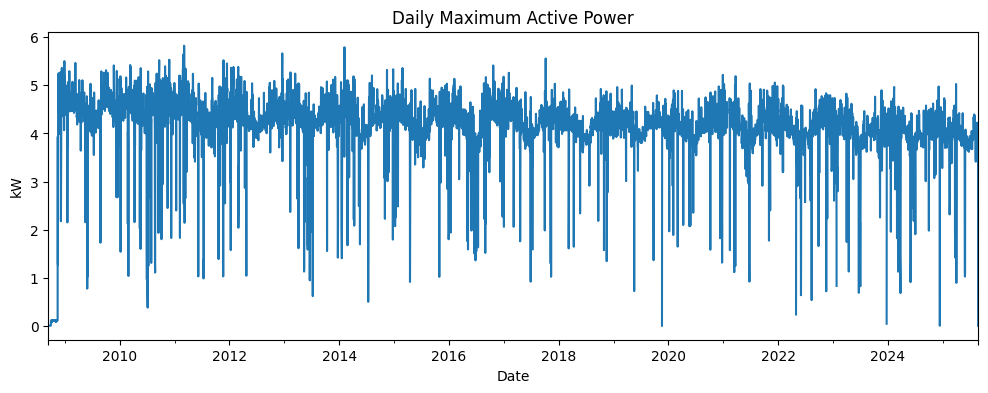

In [92]:
plt.figure(figsize=(12, 4))
daily_quality["max_power_kw"].plot()
plt.title("Daily Maximum Active Power")
plt.xlabel("Date")
plt.ylabel("kW")
plt.savefig('../results/daily_maximum_active_power.png', dpi=150)
plt.show()

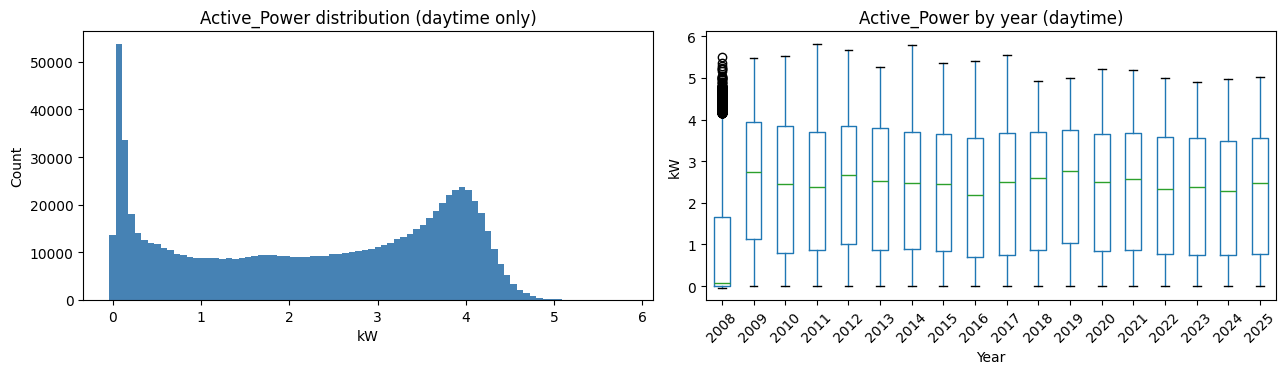


Daytime Active_Power stats:
count    817757.0000
mean          2.2709
std           1.4782
min          -0.0400
25%           0.7989
50%           2.4556
75%           3.6741
max           5.8248
Name: Active_Power, dtype: float64


In [ ]:
#Active_Power distribution (daytime only)

daytime_mask  = (df_raw['Global_Horizontal_Radiation'].fillna(0) > 20) & df_raw['Active_Power'].notna()
daytime_power = df_raw.loc[daytime_mask, 'Active_Power']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(daytime_power, bins=80, color='steelblue', edgecolor='none')
axes[0].set_title('Active_Power distribution (daytime only)')
axes[0].set_xlabel('kW')
axes[0].set_ylabel('Count')

daytime_df = df_raw.loc[daytime_mask, ['timestamp', 'Active_Power']].copy()
daytime_df['year'] = daytime_df['timestamp'].dt.year
daytime_df.boxplot(column='Active_Power', by='year', ax=axes[1], rot=45, grid=False)
axes[1].set_title('Active_Power by year (daytime)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('kW')
plt.suptitle('')

plt.tight_layout()
plt.savefig('../results/active_power_distribution.png', dpi=150)
plt.show()

print(f"\nDaytime Active_Power stats:")
print(daytime_power.describe().round(4))

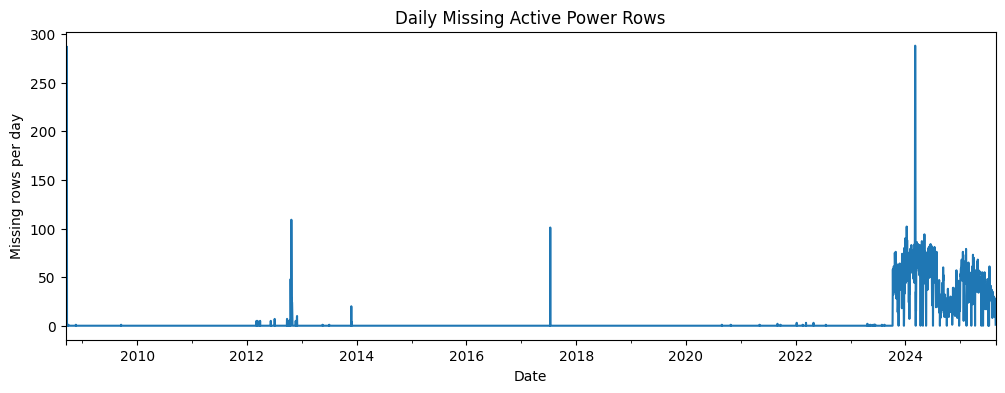

In [94]:
plt.figure(figsize=(12, 4))
daily_quality["active_power_missing"].plot()
plt.title("Daily Missing Active Power Rows")
plt.xlabel("Date")
plt.ylabel("Missing rows per day")
plt.savefig('../results/daily_missing_active_power_rows.png', dpi=150)
plt.show()

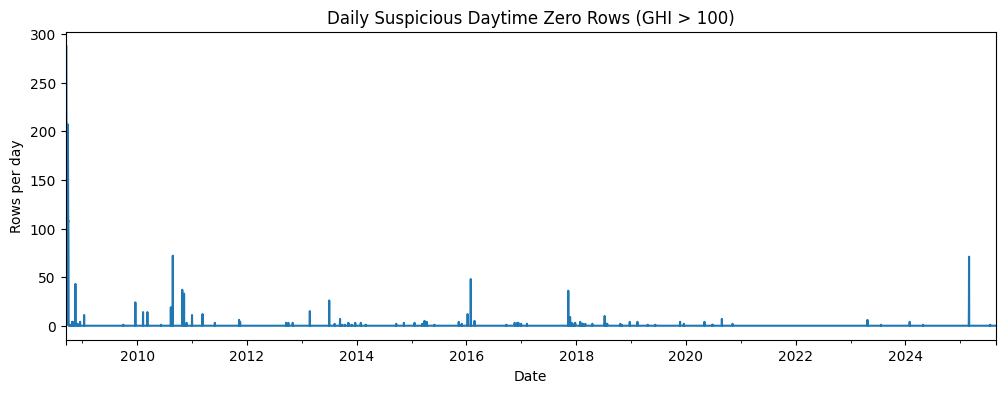

In [95]:
plt.figure(figsize=(12, 4))
daily_quality["suspicious_daytime_zero_rows"].plot()
plt.title(f"Daily Suspicious Daytime Zero Rows (GHI > {GHI_THRESHOLD_FOR_AUDIT})")
plt.xlabel("Date")
plt.ylabel("Rows per day")
plt.savefig('../results/daily_suspicious_daytime_zero_rows.png', dpi=150)
plt.show()

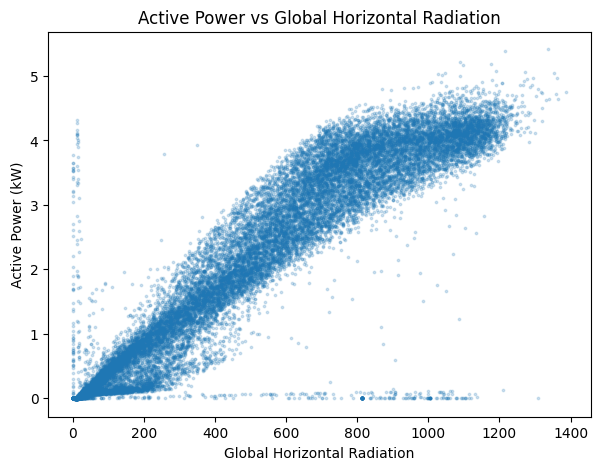

In [96]:
#Power vs irradiance scatter sample

scatter_cols = ["Active_Power", "Global_Horizontal_Radiation"]

scatter_df = df_raw[scatter_cols].dropna()

sample_size = min(50000, len(scatter_df))
scatter_sample = scatter_df.sample(sample_size, random_state=42)

plt.figure(figsize=(7, 5))
plt.scatter(
    scatter_sample["Global_Horizontal_Radiation"],
    scatter_sample["Active_Power"],
    s=3,
    alpha=0.2
)
plt.title("Active Power vs Global Horizontal Radiation")
plt.xlabel("Global Horizontal Radiation")
plt.ylabel("Active Power (kW)")
plt.savefig('../results/active_power_vs_irradiance.png', dpi=150)
plt.show()

### **3. First stage of Pre-processing**

In [101]:
temporary_eda_cols = [
    "is_power_zero",
    "is_daylight_like",
    "suspicious_daytime_zero"
]

df_base = df_raw.drop(columns=temporary_eda_cols, errors="ignore").copy()

In [102]:
print("df_base shape:", df_base.shape)
print("Columns:", len(df_base.columns))
print("Timestamp range:", df_base["timestamp"].min(), "to", df_base["timestamp"].max())

df_base shape: (1767911, 14)
Columns: 14
Timestamp range: 2008-09-12 05:55:00 to 2025-08-23 05:55:00


In [103]:
df_base.head()

,timestamp,Active_Energy_Delivered_Received,Current_Phase_Average,Active_Power,Performance_Ratio,Wind_Speed,Weather_Temperature_Celsius,Weather_Relative_Humidity,Global_Horizontal_Radiation,Diffuse_Horizontal_Radiation,Wind_Direction,Weather_Daily_Rainfall,Radiation_Global_Tilted,Radiation_Diffuse_Tilted
0,2008-09-12 05:55:00,0.0,0.0,0.0,NaN,NaN,25.734350,18.551216,5.227983,2.215820,103.423134,0.0,NaN,NaN
1,2008-09-12 06:00:00,0.0,0.0,0.0,NaN,NaN,25.402353,19.242727,5.408280,2.435364,125.776703,0.0,NaN,NaN
2,2008-09-12 06:05:00,0.0,0.0,0.0,NaN,NaN,25.141418,19.368038,4.931451,1.885518,163.055115,0.0,NaN,NaN
3,2008-09-12 06:10:00,0.0,0.0,0.0,NaN,NaN,25.015263,19.301992,4.298166,1.327833,137.553268,0.0,NaN,NaN
4,2008-09-12 06:15:00,0.0,0.0,0.0,NaN,NaN,24.935015,19.123230,4.499399,1.520790,128.099182,0.0,NaN,NaN


In [104]:
#Outage removal windows

stage1_windows = pd.DataFrame([
    {
        "window": "pre_commissioning_plus_startup_buffer",
        "start": "2008-09-12 00:00:00",
        "end": "2009-01-15 23:59:59",
        "reason": "Pre-commissioning / early raw period plus one-week startup buffer."
    },
    {
        "window": "inverter_disturbance_plus_buffer",
        "start": "2017-09-15 00:00:00",
        "end": "2018-01-26 23:59:59",
        "reason": "Known inverter output disturbance period plus one-week buffer."
    },
    {
        "window": "cabling_works_full_day",
        "start": "2018-07-09 00:00:00",
        "end": "2018-07-09 23:59:59",
        "reason": "Known cabling works / system disconnection day."
    },
    {
        "window": "combiner_box_replacement_full_day",
        "start": "2018-12-06 00:00:00",
        "end": "2018-12-06 23:59:59",
        "reason": "Known combiner box replacement day."
    }
])

stage1_windows["start"] = pd.to_datetime(stage1_windows["start"])
stage1_windows["end"] = pd.to_datetime(stage1_windows["end"])

display(stage1_windows)

,window,start,end,reason
0,pre_commissioning_plus_startup_buffer,2008-09-12,2009-01-15 23:59:59,Pre-commissioning / early raw period plus one-...
1,inverter_disturbance_plus_buffer,2017-09-15,2018-01-26 23:59:59,Known inverter output disturbance period plus ...
2,cabling_works_full_day,2018-07-09,2018-07-09 23:59:59,Known cabling works / system disconnection day.
3,combiner_box_replacement_full_day,2018-12-06,2018-12-06 23:59:59,Known combiner box replacement day.


In [105]:
#Audit Stage 1 windows before removing

window_audit_rows = []

for _, row in stage1_windows.iterrows():
    mask = df_base["timestamp"].between(row["start"], row["end"])

    suspicious_zero_mask = (
        df_base["Active_Power"].eq(0) &
        df_base["Global_Horizontal_Radiation"].gt(100)
    )

    window_audit_rows.append({
        "window": row["window"],
        "start": row["start"],
        "end": row["end"],
        "rows": int(mask.sum()),
        "active_power_missing": int(df_base.loc[mask, "Active_Power"].isna().sum()),
        "active_power_zero": int(df_base.loc[mask, "Active_Power"].eq(0).sum()),
        "suspicious_daytime_zero_ghi100": int((mask & suspicious_zero_mask).sum()),
        "max_power_kw": df_base.loc[mask, "Active_Power"].max(),
        "max_ghi": df_base.loc[mask, "Global_Horizontal_Radiation"].max(),
        "reason": row["reason"]
    })

stage1_window_audit = pd.DataFrame(window_audit_rows)

display(stage1_window_audit)

,window,start,end,rows,active_power_missing,active_power_zero,suspicious_daytime_zero_ghi100,max_power_kw,max_ghi,reason
0,pre_commissioning_plus_startup_buffer,2008-09-12,2009-01-15 23:59:59,36078,375,19588,3147,5.504600,1446.429932,Pre-commissioning / early raw period plus one-...
1,inverter_disturbance_plus_buffer,2017-09-15,2018-01-26 23:59:59,38592,0,18183,56,5.559000,2015.181641,Known inverter output disturbance period plus ...
2,cabling_works_full_day,2018-07-09,2018-07-09 23:59:59,288,0,173,10,3.977334,801.985413,Known cabling works / system disconnection day.
3,combiner_box_replacement_full_day,2018-12-06,2018-12-06 23:59:59,288,0,129,0,4.152000,1284.336914,Known combiner box replacement day.


In [106]:
stage1_remove_mask = pd.Series(False, index=df_base.index)
stage1_removal_reason = pd.Series(pd.NA, index=df_base.index, dtype="object")

for _, row in stage1_windows.iterrows():
    mask = df_base["timestamp"].between(row["start"], row["end"])

    stage1_remove_mask = stage1_remove_mask | mask
    stage1_removal_reason.loc[mask & stage1_removal_reason.isna()] = row["window"]

df_stage1_removed = df_base.loc[stage1_remove_mask].copy()
df_stage1_removed["stage1_removal_reason"] = stage1_removal_reason.loc[stage1_remove_mask].values

df_stage1 = df_base.loc[~stage1_remove_mask].copy()
df_stage1 = df_stage1.sort_values("timestamp").reset_index(drop=True)

print("Original rows:", len(df_base))
print("Removed rows:", len(df_stage1_removed))
print("Stage 1 rows:", len(df_stage1))
print("Removed %:", round(len(df_stage1_removed) / len(df_base) * 100, 3))

print("Stage 1 timestamp range:", df_stage1["timestamp"].min(), "to", df_stage1["timestamp"].max())

Original rows: 1767911
Removed rows: 75246
Stage 1 rows: 1692665
Removed %: 4.256
Stage 1 timestamp range: 2009-01-16 00:00:00 to 2025-08-23 05:55:00


In [109]:
#Quick before/after quality check

def basic_quality_report(dataframe, name):
    suspicious_zero_mask = (
        dataframe["Active_Power"].eq(0) &
        dataframe["Global_Horizontal_Radiation"].gt(100)
    )

    report = {
        "dataset": name,
        "rows": len(dataframe),
        "start": dataframe["timestamp"].min(),
        "end": dataframe["timestamp"].max(),
        "active_power_missing": int(dataframe["Active_Power"].isna().sum()),
        "active_power_zero": int(dataframe["Active_Power"].eq(0).sum()),
        "suspicious_daytime_zero_ghi100": int(suspicious_zero_mask.sum()),
        "negative_active_power": int((dataframe["Active_Power"] < 0).sum()),
        "max_active_power_kw": dataframe["Active_Power"].max(),
        "max_ghi": dataframe["Global_Horizontal_Radiation"].max()
    }

    return report


quality_before_after = pd.DataFrame([
    basic_quality_report(df_base, "before_stage1"),
    basic_quality_report(df_stage1, "after_stage1")
])

display(quality_before_after)

,dataset,rows,start,end,active_power_missing,active_power_zero,suspicious_daytime_zero_ghi100,negative_active_power,max_active_power_kw,max_ghi
0,before_stage1,1767911,2008-09-12 05:55:00,2025-08-23 05:55:00,31313,883335,3826,6690,5.8248,2725.605957
1,after_stage1,1692665,2009-01-16 00:00:00,2025-08-23 05:55:00,30938,845262,613,6513,5.8248,2725.605957


In [110]:
yearly_s1 = df_stage1.groupby(df_stage1['timestamp'].dt.year).agg(
    rows      = ('Active_Power', 'size'),
    missing   = ('Active_Power', lambda x: x.isnull().sum()),
    coverage  = ('Active_Power', lambda x: round(x.notna().sum() / len(x) * 100, 1))
)
yearly_s1.index.name = 'Year'
print(yearly_s1.to_string())

        rows  missing  coverage
Year                           
2009  100796        1     100.0
2010  105120        0     100.0
2011  104901        0     100.0
2012  105394      485      99.5
2013  105076       26     100.0
2014  105111        0     100.0
2015  105120        0     100.0
2016  105408        0     100.0
2017   73510      101      99.9
2018   97056        0     100.0
2019  102905        0     100.0
2020  105381        2     100.0
2021  100539        4     100.0
2022  102901       11     100.0
2023  101797     4038      96.0
2024  104244    16863      83.8
2025   67406     9407      86.0


**Stage 1 re-audit before further cleaning**

In [120]:
s1 = df_stage1.copy()

s1["timestamp"] = pd.to_datetime(s1["timestamp"])
s1 = s1.sort_values("timestamp").reset_index(drop=True)

print("Stage 1 shape:", s1.shape)
print("Timestamp range:", s1["timestamp"].min(), "to", s1["timestamp"].max())
print("Columns:", s1.columns.tolist())

Stage 1 shape: (1692665, 14)
Timestamp range: 2009-01-16 00:00:00 to 2025-08-23 05:55:00
Columns: ['timestamp', 'Active_Energy_Delivered_Received', 'Current_Phase_Average', 'Active_Power', 'Performance_Ratio', 'Wind_Speed', 'Weather_Temperature_Celsius', 'Weather_Relative_Humidity', 'Global_Horizontal_Radiation', 'Diffuse_Horizontal_Radiation', 'Wind_Direction', 'Weather_Daily_Rainfall', 'Radiation_Global_Tilted', 'Radiation_Diffuse_Tilted']


In [ ]:
#Column availability by year

availability_by_year = (
    s1
    .groupby(s1["timestamp"].dt.year)
    .apply(lambda g: g.notna().mean() * 100)
    .round(1)
)

availability_by_year.index.name = "Year"

display(availability_by_year)

,timestamp,Active_Energy_Delivered_Received,Current_Phase_Average,Active_Power,Performance_Ratio,Wind_Speed,Weather_Temperature_Celsius,Weather_Relative_Humidity,Global_Horizontal_Radiation,Diffuse_Horizontal_Radiation,Wind_Direction,Weather_Daily_Rainfall,Radiation_Global_Tilted,Radiation_Diffuse_Tilted
Year,,,,,,,,,,,,,,
2009,100.0,100.0,100.0,100.0,0.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,0.0,0.0
2010,100.0,100.0,100.0,100.0,0.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,0.0,0.0
2011,100.0,100.0,100.0,100.0,0.0,99.5,99.5,99.5,99.5,99.5,99.5,99.5,0.0,0.0
2012,100.0,99.5,99.5,99.5,0.0,99.0,99.5,99.5,99.5,99.5,99.0,99.5,0.0,0.0
2013,100.0,100.0,100.0,100.0,0.0,98.4,100.0,100.0,100.0,100.0,98.4,100.0,58.2,58.2
2014,100.0,100.0,100.0,100.0,0.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,72.8,97.1
2015,100.0,100.0,100.0,100.0,59.3,100.0,100.0,100.0,100.0,100.0,100.0,100.0,83.8,99.6
2016,100.0,100.0,100.0,100.0,100.0,80.5,100.0,100.0,100.0,100.0,100.0,100.0,98.7,98.7
2017,100.0,99.9,99.9,99.9,99.9,0.0,99.9,99.9,99.9,99.9,99.9,99.9,100.0,100.0


In [ ]:
#Active_Power monthly coverage after Stage 1

#This is mainly to locate the late-2023/2024 missingness problem.

s1_indexed = s1.set_index("timestamp")

monthly_target = pd.DataFrame(index=s1_indexed.resample("ME").size().index)

monthly_target["rows"] = s1_indexed["Active_Power"].resample("ME").size()
monthly_target["missing_active_power"] = s1_indexed["Active_Power"].resample("ME").apply(lambda x: x.isna().sum())
monthly_target["coverage_pct"] = (
    100 * (monthly_target["rows"] - monthly_target["missing_active_power"]) / monthly_target["rows"]
).round(2)

monthly_target["zero_active_power"] = s1_indexed["Active_Power"].resample("ME").apply(lambda x: x.eq(0).sum())

monthly_target["month"] = monthly_target.index.to_period("M").astype(str)

display(monthly_target[monthly_target.index >= "2023-01-01"])

,rows,missing_active_power,coverage_pct,zero_active_power,month
timestamp,,,,,
2023-01-31,7132,0,100.00,3257,2023-01
2023-02-28,8049,0,100.00,3787,2023-02
2023-03-31,8884,0,100.00,4453,2023-03
2023-04-30,8630,2,99.98,4573,2023-04
2023-05-31,8926,3,99.97,4909,2023-05
2023-06-30,8500,3,99.96,4803,2023-06
2023-07-31,8849,1,99.99,4953,2023-07
2023-08-31,8846,1,99.99,4705,2023-08
2023-09-30,8640,0,100.00,4398,2023-09


In [125]:
#bad months

bad_months_target = monthly_target[
    monthly_target["coverage_pct"] < 99.5
].sort_values("coverage_pct")

display(bad_months_target.head(30))

,rows,missing_active_power,coverage_pct,zero_active_power,month
timestamp,,,,,
2024-03-31,8262,2549,69.15,2975,2024-03
2024-02-29,8348,1898,77.26,3078,2024-02
2024-06-30,8634,1839,78.70,3870,2024-06
2024-01-31,8875,1874,78.88,3168,2024-01
2024-05-31,8922,1754,80.34,3939,2024-05
2025-01-31,8916,1730,80.60,3293,2025-01
2024-04-30,8615,1663,80.70,3732,2024-04
2023-12-31,7871,1442,81.68,2894,2023-12
2024-07-31,8925,1517,83.00,4170,2024-07


In [126]:
#Daily missingness after 2023

daily_target = pd.DataFrame(index=s1_indexed.resample("D").size().index)

daily_target["rows"] = s1_indexed["Active_Power"].resample("D").size()
daily_target["missing_active_power"] = s1_indexed["Active_Power"].resample("D").apply(lambda x: x.isna().sum())
daily_target["coverage_pct"] = (
    100 * (daily_target["rows"] - daily_target["missing_active_power"]) / daily_target["rows"]
).round(2)

daily_target["max_power_kw"] = s1_indexed["Active_Power"].resample("D").max()
daily_target["max_ghi"] = s1_indexed["Global_Horizontal_Radiation"].resample("D").max()

daily_target_2023_onward = daily_target[daily_target.index >= "2023-01-01"]

print("First days after 2023 with missing Active_Power:")
display(daily_target_2023_onward[daily_target_2023_onward["missing_active_power"] > 0].head(30))

print("Worst days after 2023 by missing Active_Power:")
display(
    daily_target_2023_onward
    .sort_values("missing_active_power", ascending=False)
    .head(30)
)

First days after 2023 with missing Active_Power:


,rows,missing_active_power,coverage_pct,max_power_kw,max_ghi
timestamp,,,,,
2023-04-22,287,2,99.30,4.083533,927.676208
2023-05-02,288,1,99.65,4.369166,974.371521
2023-05-14,288,1,99.65,4.335700,996.454285
2023-05-31,288,1,99.65,3.733434,804.388916
2023-06-08,166,1,99.40,3.824933,787.188538
2023-06-10,288,1,99.65,3.779399,784.031006
2023-06-14,288,1,99.65,3.816166,777.006348
2023-07-28,288,1,99.65,3.702133,820.215027
2023-08-14,288,1,99.65,3.801800,891.709290


Worst days after 2023 by missing Active_Power:


,rows,missing_active_power,coverage_pct,max_power_kw,max_ghi
timestamp,,,,,
2024-03-06,288,288,0.00,NaN,NaN
2024-03-05,288,288,0.00,NaN,NaN
2024-03-07,288,173,39.93,4.464600,1238.159668
2024-03-04,288,150,47.92,3.744600,979.803101
2024-01-09,288,102,64.58,3.976933,1185.747192
2024-05-06,287,94,67.25,3.956100,868.603760
2023-12-31,276,90,67.39,4.003800,1224.512695
2024-01-12,288,88,69.44,3.860734,1150.888794
2024-04-19,288,87,69.79,4.231433,973.358337


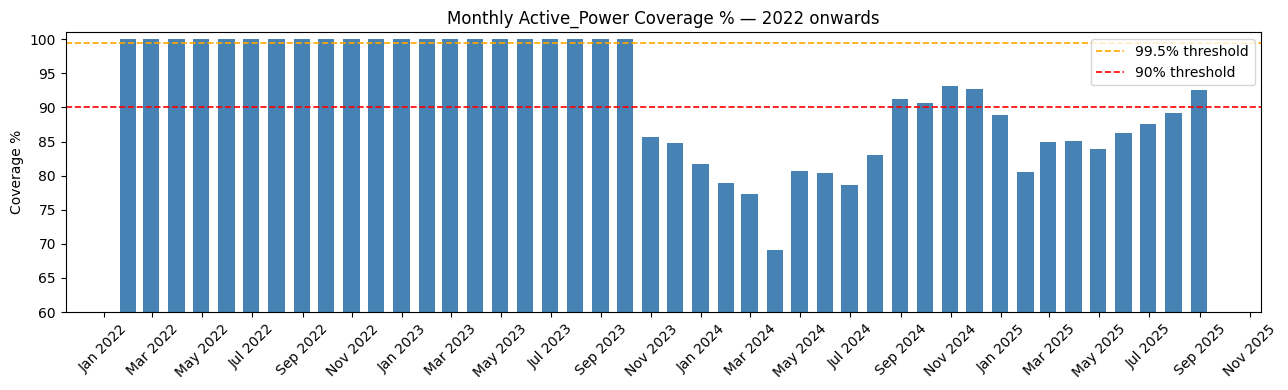

In [137]:
# monthly_target already exists from earlier cell
# Filter to 2022 onwards to show the cliff clearly
monthly_recent = monthly_target["2022":]

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(monthly_recent.index, monthly_recent["coverage_pct"],
       width=20, color="steelblue", edgecolor="none")
ax.axhline(99.5, color="orange", linewidth=1.2, linestyle="--", label="99.5% threshold")
ax.axhline(90, color="red", linewidth=1.2, linestyle="--", label="90% threshold")
ax.set_ylim(60, 101)
ax.set_title("Monthly Active_Power Coverage % — 2022 onwards")
ax.set_ylabel("Coverage %")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig("../results/monthly_coverage_2022_onwards.png", dpi=150)
plt.show()

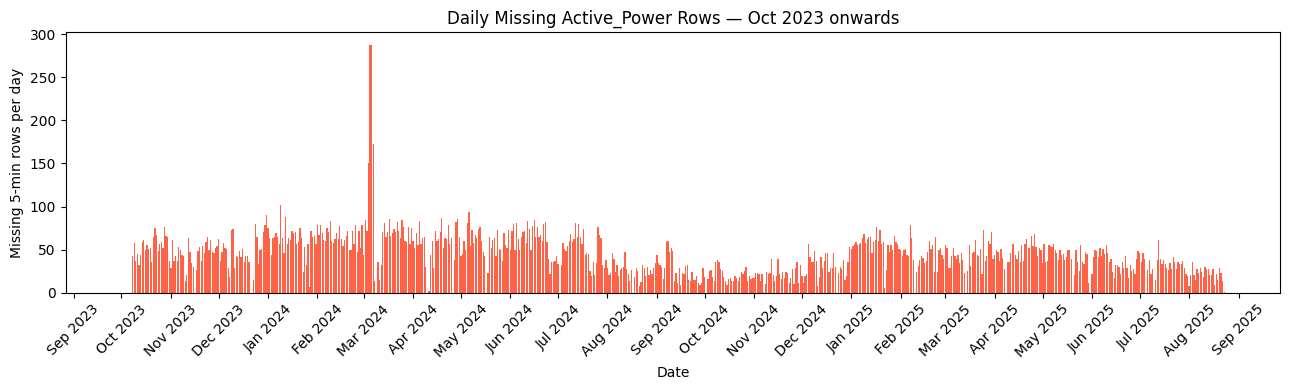

In [138]:
# daily_target already exists from earlier cell
daily_recent = daily_target["2023-10":]

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(daily_recent.index, daily_recent["missing_active_power"],
       width=0.8, color="tomato", edgecolor="none")
ax.set_title("Daily Missing Active_Power Rows — Oct 2023 onwards")
ax.set_ylabel("Missing 5-min rows per day")
ax.set_xlabel("Date")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../results/daily_missing_oct2023_onwards.png", dpi=150)
plt.show()

In [144]:
s1 = df_stage1.copy()

s1["timestamp"] = pd.to_datetime(s1["timestamp"])
s1 = s1.sort_values("timestamp").reset_index(drop=True)

print("Stage 1 shape:", s1.shape)
print("Stage 1 timestamp range:", s1["timestamp"].min(), "to", s1["timestamp"].max())

Stage 1 shape: (1692665, 14)
Stage 1 timestamp range: 2009-01-16 00:00:00 to 2025-08-23 05:55:00


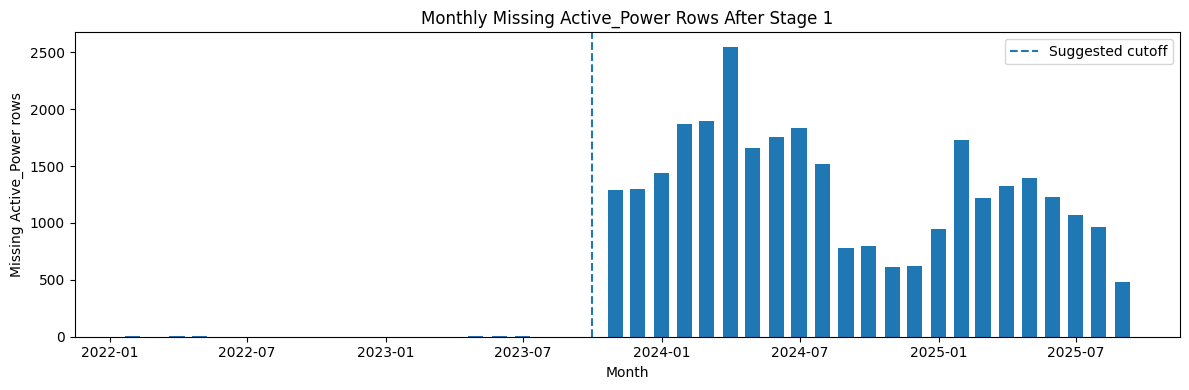

In [146]:
s1_indexed = s1.set_index("timestamp")

monthly_missing = pd.DataFrame(index=s1_indexed.resample("ME").size().index)

monthly_missing["rows"] = s1_indexed["Active_Power"].resample("ME").size()
monthly_missing["missing_active_power"] = (
    s1_indexed["Active_Power"]
    .resample("ME")
    .apply(lambda x: x.isna().sum())
)

monthly_missing["coverage_pct"] = (
    100 * (monthly_missing["rows"] - monthly_missing["missing_active_power"]) 
    / monthly_missing["rows"]
).round(2)

plot_data = monthly_missing[monthly_missing.index >= "2022-01-01"]

plt.figure(figsize=(12, 4))
plt.bar(plot_data.index, plot_data["missing_active_power"], width=20)
plt.axvline(pd.Timestamp("2023-10-01"), linestyle="--", label="Suggested cutoff")
plt.title("Monthly Missing Active_Power Rows After Stage 1")
plt.xlabel("Month")
plt.ylabel("Missing Active_Power rows")
plt.legend()
plt.tight_layout()
plt.savefig("../results/monthly_missing_active_power_after_stage1.png", dpi=150)
plt.show()

In [127]:
#Compare possible modeling windows

#This is important before deciding whether to exclude 2024/2025.

def summarize_candidate_window(dataframe, name, start=None, end=None):
    temp = dataframe.copy()

    if start is not None:
        temp = temp[temp["timestamp"] >= pd.Timestamp(start)]
    if end is not None:
        temp = temp[temp["timestamp"] <= pd.Timestamp(end)]

    suspicious_zero = (
        temp["Active_Power"].eq(0) &
        temp["Global_Horizontal_Radiation"].gt(100)
    )

    return {
        "window": name,
        "start": temp["timestamp"].min(),
        "end": temp["timestamp"].max(),
        "rows": len(temp),
        "active_power_missing": int(temp["Active_Power"].isna().sum()),
        "active_power_coverage_pct": round(temp["Active_Power"].notna().mean() * 100, 3),
        "suspicious_daytime_zero_ghi100": int(suspicious_zero.sum()),
        "negative_power_rows": int((temp["Active_Power"] < 0).sum()),
        "ghi_above_1300_rows": int((temp["Global_Horizontal_Radiation"] > 1300).sum()),
        "humidity_above_100_rows": int((temp["Weather_Relative_Humidity"] > 100).sum()),
        "temp_below_minus10_rows": int((temp["Weather_Temperature_Celsius"] < -10).sum())
    }


candidate_windows = pd.DataFrame([
    summarize_candidate_window(s1, "Stage 1 full range"),
    summarize_candidate_window(s1, "2009-01-16 to 2022-12-31", end="2022-12-31 23:59:59"),
    summarize_candidate_window(s1, "2009-01-16 to 2023-12-31", end="2023-12-31 23:59:59"),
    summarize_candidate_window(s1, "2010-01-01 to 2022-12-31", start="2010-01-01", end="2022-12-31 23:59:59"),
    summarize_candidate_window(s1, "2010-01-01 to 2023-12-31", start="2010-01-01", end="2023-12-31 23:59:59")
])

display(candidate_windows)

,window,start,end,rows,active_power_missing,active_power_coverage_pct,suspicious_daytime_zero_ghi100,negative_power_rows,ghi_above_1300_rows,humidity_above_100_rows,temp_below_minus10_rows
0,Stage 1 full range,2009-01-16,2025-08-23 05:55:00,1692665,30938,98.172,613,6513,461,14302,3047
1,2009-01-16 to 2022-12-31,2009-01-16,2022-12-31 23:55:00,1419218,630,99.956,509,6143,396,8346,3047
2,2009-01-16 to 2023-12-31,2009-01-16,2023-12-31 23:55:00,1521015,4668,99.693,516,6327,413,10793,3047
3,2010-01-01 to 2022-12-31,2010-01-01,2022-12-31 23:55:00,1318422,629,99.952,484,5815,391,8346,3047
4,2010-01-01 to 2023-12-31,2010-01-01,2023-12-31 23:55:00,1420219,4667,99.671,491,5999,408,10793,3047


In [128]:
#Suspicious daytime zero threshold audit after Stage 1

thresholds = [20, 50, 100, 200, 300]

suspicious_rows = []

for threshold in thresholds:
    exact_zero = (
        s1["Active_Power"].eq(0) &
        s1["Global_Horizontal_Radiation"].gt(threshold)
    )

    near_zero = (
        s1["Active_Power"].le(0.01) &
        s1["Global_Horizontal_Radiation"].gt(threshold)
    )

    suspicious_rows.append({
        "ghi_threshold": threshold,
        "exact_zero_rows": int(exact_zero.sum()),
        "near_zero_power_le_0_01_rows": int(near_zero.sum()),
        "exact_zero_pct": round(exact_zero.mean() * 100, 4),
        "near_zero_pct": round(near_zero.mean() * 100, 4)
    })

suspicious_threshold_stage1 = pd.DataFrame(suspicious_rows)
display(suspicious_threshold_stage1)

,ghi_threshold,exact_zero_rows,near_zero_power_le_0_01_rows,exact_zero_pct,near_zero_pct
0,20,2603,3578,0.1538,0.2114
1,50,686,721,0.0405,0.0426
2,100,613,623,0.0362,0.0368
3,200,542,549,0.0320,0.0324
4,300,465,471,0.0275,0.0278


In [129]:
suspicious_g100 = (
    s1["Active_Power"].eq(0) &
    s1["Global_Horizontal_Radiation"].gt(100)
)

suspicious_by_year = (
    pd.Series(suspicious_g100.to_numpy(), index=s1["timestamp"])
    .resample("YE")
    .sum()
)

suspicious_by_year.index = suspicious_by_year.index.year
display(suspicious_by_year)

timestamp
2009     25
2010    205
2011     36
2012     10
2013     61
2014      9
2015     22
2016     81
2017      2
2018     31
2019     12
2020     15
2021      0
2022      0
2023      7
2024      5
2025     92
dtype: int64

In [130]:
#Remaining suspicious zero runs

def summarize_flag_runs(dataframe, mask, label, max_rows=30):
    mask = pd.Series(mask, index=dataframe.index).fillna(False)

    groups = (mask != mask.shift()).cumsum()

    runs = (
        dataframe.loc[mask]
        .groupby(groups[mask])["timestamp"]
        .agg(start="min", end="max", rows="size")
        .reset_index(drop=True)
    )

    if len(runs) == 0:
        print(f"No runs found for: {label}")
        return pd.DataFrame()

    runs["duration"] = runs["end"] - runs["start"] + pd.Timedelta(minutes=5)
    runs = runs.sort_values(["rows", "start"], ascending=[False, True]).reset_index(drop=True)

    print(label)
    print("Total flagged rows:", int(mask.sum()))
    print("Number of separate runs:", len(runs))

    display(runs.head(max_rows))
    return runs


suspicious_zero_runs_s1 = summarize_flag_runs(
    s1,
    suspicious_g100,
    "Stage 1 suspicious daytime zero runs: Active_Power = 0 and GHI > 100"
)

Stage 1 suspicious daytime zero runs: Active_Power = 0 and GHI > 100
Total flagged rows: 613
Number of separate runs: 101


,start,end,rows,duration
0,2010-08-26 07:35:00,2010-08-26 13:30:00,72,0 days 06:00:00
1,2016-01-30 14:40:00,2016-01-30 18:20:00,45,0 days 03:45:00
2,2010-10-28 14:30:00,2010-10-28 17:30:00,37,0 days 03:05:00
3,2010-11-09 07:00:00,2010-11-09 09:40:00,33,0 days 02:45:00
4,2013-07-02 11:25:00,2013-07-02 13:30:00,26,0 days 02:10:00
5,2009-12-20 08:15:00,2009-12-20 10:10:00,24,0 days 02:00:00
6,2010-08-13 08:40:00,2010-08-13 10:10:00,19,0 days 01:35:00
7,2025-02-27 11:50:00,2025-02-27 13:20:00,19,0 days 01:35:00
8,2013-02-23 17:15:00,2013-02-23 18:25:00,15,0 days 01:15:00
9,2010-02-09 11:25:00,2010-02-09 12:30:00,14,0 days 01:10:00


In [131]:
#Opposite anomaly: high power while GHI is near zero

opposite_anomaly_rows = []

for power_threshold in [0.5, 1.0, 2.0]:
    for ghi_threshold in [5, 20, 50]:
        mask = (
            s1["Active_Power"].gt(power_threshold) &
            s1["Global_Horizontal_Radiation"].lt(ghi_threshold)
        )

        opposite_anomaly_rows.append({
            "power_threshold_kw": power_threshold,
            "ghi_below": ghi_threshold,
            "rows": int(mask.sum()),
            "pct": round(mask.mean() * 100, 5)
        })

opposite_anomaly_summary = pd.DataFrame(opposite_anomaly_rows)
display(opposite_anomaly_summary)

,power_threshold_kw,ghi_below,rows,pct
0,0.5,5,1563,0.09234
1,0.5,20,2851,0.16843
2,0.5,50,3684,0.21764
3,1.0,5,1186,0.07007
4,1.0,20,2297,0.13570
5,1.0,50,2567,0.15165
6,2.0,5,722,0.04265
7,2.0,20,1566,0.09252
8,2.0,50,1581,0.09340


In [132]:
high_power_low_ghi = (
    s1["Active_Power"].gt(1.0) &
    s1["Global_Horizontal_Radiation"].lt(20)
)

inspect_cols = [
    "timestamp",
    "Active_Power",
    "Global_Horizontal_Radiation",
    "Diffuse_Horizontal_Radiation",
    "Weather_Temperature_Celsius",
    "Weather_Relative_Humidity",
    "Current_Phase_Average"
]

inspect_cols = [c for c in inspect_cols if c in s1.columns]

display(
    s1.loc[high_power_low_ghi, inspect_cols]
    .sort_values("timestamp")
    .head(30)
)

display(
    s1.loc[high_power_low_ghi, inspect_cols]
    .sort_values("timestamp")
    .tail(30)
)

,timestamp,Active_Power,Global_Horizontal_Radiation,Diffuse_Horizontal_Radiation,Weather_Temperature_Celsius,Weather_Relative_Humidity,Current_Phase_Average
688439,2015-08-04 10:05:00,3.630333,-985.690002,310.63504,11.866037,50.987556,14.974000
780318,2016-06-18 10:40:00,1.126267,0.000000,0.00000,0.000000,0.000000,4.831333
780319,2016-06-18 10:45:00,1.408667,0.000000,0.00000,0.000000,0.000000,5.984666
780320,2016-06-18 10:50:00,1.283400,0.000000,0.00000,0.000000,0.000000,5.476666
780321,2016-06-18 10:55:00,1.157467,0.000000,0.00000,0.000000,0.000000,4.962666
780322,2016-06-18 11:00:00,1.045333,0.000000,0.00000,0.000000,0.000000,4.498667
780323,2016-06-18 11:05:00,1.405200,0.000000,0.00000,0.000000,0.000000,5.969333
780324,2016-06-18 11:10:00,1.498067,0.000000,0.00000,0.000000,0.000000,6.352667
780325,2016-06-18 11:15:00,1.322267,0.000000,0.00000,0.000000,0.000000,5.636000
780326,2016-06-18 11:20:00,1.028333,0.000000,0.00000,0.000000,0.000000,4.448667


,timestamp,Active_Power,Global_Horizontal_Radiation,Diffuse_Horizontal_Radiation,Weather_Temperature_Celsius,Weather_Relative_Humidity,Current_Phase_Average
1130404,2020-03-10 11:15:00,3.985466,11.737370,2.891714,-35.533298,4.216981,16.268665
1130405,2020-03-10 11:20:00,4.003800,11.660161,2.856253,-36.177284,3.577904,16.343996
1130406,2020-03-10 11:25:00,4.034867,11.682399,2.847134,-36.822536,2.960287,16.473999
1130407,2020-03-10 11:30:00,4.037333,11.686353,2.848353,-36.648212,3.142710,16.479332
1130408,2020-03-10 11:35:00,4.072600,11.705172,2.829880,-36.443844,3.321523,16.625338
1130409,2020-03-10 11:40:00,4.102933,11.694210,2.833433,-36.760792,3.022306,16.745998
1130410,2020-03-10 11:45:00,4.094800,11.707516,2.803553,-36.718502,3.061512,16.717337
1130411,2020-03-10 11:50:00,4.110867,11.688626,2.797268,-36.558910,3.209722,16.785330
1130412,2020-03-10 11:55:00,4.123933,11.643682,2.792299,-37.131203,2.674407,16.837328
1130413,2020-03-10 12:00:00,4.132266,11.623320,2.810663,-36.786320,3.001583,16.875328


In [133]:
#Physical sanity checks after Stage 1

physical_checks = {}

physical_checks["active_power_negative"] = s1["Active_Power"] < -0.01
physical_checks["active_power_above_5_8_kw"] = s1["Active_Power"] > 5.8
physical_checks["ghi_negative"] = s1["Global_Horizontal_Radiation"] < -5
physical_checks["ghi_above_1300"] = s1["Global_Horizontal_Radiation"] > 1300
physical_checks["diffuse_negative"] = s1["Diffuse_Horizontal_Radiation"] < -5
physical_checks["diffuse_above_1300"] = s1["Diffuse_Horizontal_Radiation"] > 1300
physical_checks["temperature_below_minus10"] = s1["Weather_Temperature_Celsius"] < -10
physical_checks["temperature_above_60"] = s1["Weather_Temperature_Celsius"] > 60
physical_checks["humidity_below_0"] = s1["Weather_Relative_Humidity"] < 0
physical_checks["humidity_above_100"] = s1["Weather_Relative_Humidity"] > 100

if "Wind_Speed" in s1.columns:
    physical_checks["wind_speed_negative"] = s1["Wind_Speed"] < 0
    physical_checks["wind_speed_above_40"] = s1["Wind_Speed"] > 40

physical_summary = []

for check_name, mask in physical_checks.items():
    physical_summary.append({
        "check": check_name,
        "rows": int(mask.sum()),
        "pct": round(mask.mean() * 100, 5)
    })

physical_summary = pd.DataFrame(physical_summary).sort_values("rows", ascending=False)

display(physical_summary)

,check,rows,pct
9,humidity_above_100,14302,0.84494
6,temperature_below_minus10,3047,0.18001
3,ghi_above_1300,461,0.02724
0,active_power_negative,371,0.02192
10,wind_speed_negative,16,0.00095
11,wind_speed_above_40,5,0.00030
5,diffuse_above_1300,2,0.00012
7,temperature_above_60,2,0.00012
2,ghi_negative,1,0.00006
1,active_power_above_5_8_kw,1,0.00006


In [134]:
physical_by_year = pd.DataFrame(index=sorted(s1["timestamp"].dt.year.unique()))

for check_name, mask in physical_checks.items():
    temp = pd.Series(mask.to_numpy(), index=s1["timestamp"])
    yearly_counts = temp.resample("YE").sum()
    yearly_counts.index = yearly_counts.index.year
    physical_by_year[check_name] = yearly_counts

physical_by_year = physical_by_year.fillna(0).astype(int)

display(physical_by_year)

,active_power_negative,active_power_above_5_8_kw,ghi_negative,ghi_above_1300,diffuse_negative,diffuse_above_1300,temperature_below_minus10,temperature_above_60,humidity_below_0,humidity_above_100,wind_speed_negative,wind_speed_above_40
2009,8,0,0,5,0,0,0,0,0,0,1,0
2010,10,0,0,11,0,0,0,0,0,0,6,0
2011,65,1,0,21,0,0,0,0,0,0,3,0
2012,57,0,0,37,0,2,0,0,0,0,0,0
2013,28,0,0,39,0,0,0,0,0,0,0,0
2014,64,0,0,37,0,0,0,0,0,363,1,0
2015,45,0,1,26,0,0,0,0,0,923,0,2
2016,38,0,0,36,0,0,5,0,0,2198,5,3
2017,56,0,0,16,0,0,0,0,0,273,0,0
2018,0,0,0,18,0,0,638,0,0,828,0,0


In [135]:
#Feature availability and preliminary keep/drop audit

#This does not drop anything. It only creates a clean decision table.

overall_missing_pct = (s1.isna().mean() * 100).round(2)

after_2017 = s1[s1["timestamp"] >= "2017-01-01"]
after_2017_missing_pct = (after_2017.isna().mean() * 100).round(2)

feature_notes = {
    "timestamp": "keep - time index",
    "Active_Power": "target - keep",
    "Global_Horizontal_Radiation": "likely keep/audit - important daylight and irradiance feature",
    "Diffuse_Horizontal_Radiation": "likely keep/audit - useful irradiance feature",
    "Weather_Temperature_Celsius": "likely keep after sensor cleaning",
    "Weather_Relative_Humidity": "likely keep after sensor cleaning",
    "Weather_Daily_Rainfall": "optional feature",
    "Radiation_Global_Tilted": "TBD based on availability by year",
    "Radiation_Diffuse_Tilted": "TBD based on availability by year",
    "Wind_Speed": "likely drop for full-period model due to high missingness",
    "Wind_Direction": "likely drop initially - weak relevance and paired with wind",
    "Performance_Ratio": "drop - derived metric, leakage risk, high missingness",
    "Current_Phase_Average": "drop initially - electrically redundant with Active_Power",
    "Active_Energy_Delivered_Received": "drop initially - cumulative counter, not direct forecasting feature"
}

feature_audit = pd.DataFrame({
    "column": s1.columns,
    "overall_missing_pct": [overall_missing_pct.get(c, np.nan) for c in s1.columns],
    "missing_pct_after_2017": [after_2017_missing_pct.get(c, np.nan) for c in s1.columns],
    "preliminary_note": [feature_notes.get(c, "review") for c in s1.columns]
})

display(feature_audit.sort_values("overall_missing_pct", ascending=False))

,column,overall_missing_pct,missing_pct_after_2017,preliminary_note
5,Wind_Speed,51.96,100.00,likely drop for full-period model due to high ...
4,Performance_Ratio,41.33,3.56,"drop - derived metric, leakage risk, high miss..."
12,Radiation_Global_Tilted,35.32,10.61,TBD based on availability by year
13,Radiation_Diffuse_Tilted,32.84,10.61,TBD based on availability by year
10,Wind_Direction,2.25,4.07,likely drop initially - weak relevance and pai...
6,Weather_Temperature_Celsius,2.12,4.07,likely keep after sensor cleaning
9,Diffuse_Horizontal_Radiation,2.12,4.07,likely keep/audit - useful irradiance feature
8,Global_Horizontal_Radiation,2.12,4.07,likely keep/audit - important daylight and irr...
7,Weather_Relative_Humidity,2.12,4.07,likely keep after sensor cleaning
11,Weather_Daily_Rainfall,2.12,4.07,optional feature


### **3. Pre-processing Stage 2A — Audit late-period missingness and choose modeling window**

In [ ]:
MODEL_START_DATE = "2009-01-16 00:00:00"
MODEL_END_DATE = "2023-09-30 23:59:59"

df_stage2a = s1[
    (s1["timestamp"] >= pd.Timestamp(MODEL_START_DATE)) &
    (s1["timestamp"] <= pd.Timestamp(MODEL_END_DATE))
].copy()

df_stage2a = df_stage2a.sort_values("timestamp").reset_index(drop=True)

print("df_stage2a created.")
print("Shape:", df_stage2a.shape)
print("Timestamp range:", df_stage2a["timestamp"].min(), "to", df_stage2a["timestamp"].max())
print("Active_Power missing:", df_stage2a["Active_Power"].isna().sum())
print("Active_Power coverage %:", round(df_stage2a["Active_Power"].notna().mean() * 100, 3))

df_stage2a created.
Shape: (1495674, 14)
Timestamp range: 2009-01-16 00:00:00 to 2023-09-30 23:55:00
Active_Power missing: 640
Active_Power coverage %: 99.957


In [148]:
#Compare Stage 1 full range vs selected modeling window

def quick_quality_summary(dataframe, name):
    suspicious_zero = (
        dataframe["Active_Power"].eq(0) &
        dataframe["Global_Horizontal_Radiation"].gt(100)
    )

    return {
        "dataset": name,
        "rows": len(dataframe),
        "start": dataframe["timestamp"].min(),
        "end": dataframe["timestamp"].max(),
        "active_power_missing": int(dataframe["Active_Power"].isna().sum()),
        "active_power_coverage_pct": round(dataframe["Active_Power"].notna().mean() * 100, 3),
        "suspicious_daytime_zero_ghi100": int(suspicious_zero.sum()),
        "active_power_negative": int((dataframe["Active_Power"] < -0.01).sum()),
        "ghi_above_1300": int((dataframe["Global_Horizontal_Radiation"] > 1300).sum()),
        "humidity_above_100": int((dataframe["Weather_Relative_Humidity"] > 100).sum()),
        "temperature_below_minus10": int((dataframe["Weather_Temperature_Celsius"] < -10).sum())
    }


stage2a_comparison = pd.DataFrame([
    quick_quality_summary(s1, "stage1_full_range"),
    quick_quality_summary(df_stage2a, "stage2a_selected_window")
])

display(stage2a_comparison)

,dataset,rows,start,end,active_power_missing,active_power_coverage_pct,suspicious_daytime_zero_ghi100,active_power_negative,ghi_above_1300,humidity_above_100,temperature_below_minus10
0,stage1_full_range,1692665,2009-01-16,2025-08-23 05:55:00,30938,98.172,613,371,461,14302,3047
1,stage2a_selected_window,1495674,2009-01-16,2023-09-30 23:55:00,640,99.957,516,371,405,10471,3047


In [149]:
#Feature availability after selecting modeling window

availability_stage2a = (
    df_stage2a
    .groupby(df_stage2a["timestamp"].dt.year)
    .apply(lambda g: g.notna().mean() * 100)
    .round(1)
)

availability_cols = [
    "Active_Power",
    "Global_Horizontal_Radiation",
    "Diffuse_Horizontal_Radiation",
    "Radiation_Global_Tilted",
    "Radiation_Diffuse_Tilted",
    "Weather_Temperature_Celsius",
    "Weather_Relative_Humidity",
    "Weather_Daily_Rainfall",
    "Wind_Speed",
    "Wind_Direction",
    "Performance_Ratio",
    "Current_Phase_Average",
    "Active_Energy_Delivered_Received"
]

availability_cols = [c for c in availability_cols if c in availability_stage2a.columns]

display(availability_stage2a[availability_cols])

,Active_Power,Global_Horizontal_Radiation,Diffuse_Horizontal_Radiation,Radiation_Global_Tilted,Radiation_Diffuse_Tilted,Weather_Temperature_Celsius,Weather_Relative_Humidity,Weather_Daily_Rainfall,Wind_Speed,Wind_Direction,Performance_Ratio,Current_Phase_Average,Active_Energy_Delivered_Received
timestamp,,,,,,,,,,,,,
2009,100.0,100.0,100.0,0.0,0.0,100.0,100.0,100.0,100.0,100.0,0.0,100.0,100.0
2010,100.0,100.0,100.0,0.0,0.0,100.0,100.0,100.0,100.0,100.0,0.0,100.0,100.0
2011,100.0,99.5,99.5,0.0,0.0,99.5,99.5,99.5,99.5,99.5,0.0,100.0,100.0
2012,99.5,99.5,99.5,0.0,0.0,99.5,99.5,99.5,99.0,99.0,0.0,99.5,99.5
2013,100.0,100.0,100.0,58.2,58.2,100.0,100.0,100.0,98.4,98.4,0.0,100.0,100.0
2014,100.0,100.0,100.0,72.8,97.1,100.0,100.0,100.0,100.0,100.0,0.0,100.0,100.0
2015,100.0,100.0,100.0,83.8,99.6,100.0,100.0,100.0,100.0,100.0,59.3,100.0,100.0
2016,100.0,100.0,100.0,98.7,98.7,100.0,100.0,100.0,80.5,100.0,100.0,100.0,100.0
2017,99.9,99.9,99.9,100.0,100.0,99.9,99.9,99.9,0.0,99.9,99.9,99.9,99.9


In [150]:
#Recheck suspicious daytime zeros in selected window

thresholds = [20, 50, 100, 200, 300]

suspicious_stage2a_rows = []

for threshold in thresholds:
    exact_zero = (
        df_stage2a["Active_Power"].eq(0) &
        df_stage2a["Global_Horizontal_Radiation"].gt(threshold)
    )

    near_zero = (
        df_stage2a["Active_Power"].le(0.01) &
        df_stage2a["Global_Horizontal_Radiation"].gt(threshold)
    )

    suspicious_stage2a_rows.append({
        "ghi_threshold": threshold,
        "exact_zero_rows": int(exact_zero.sum()),
        "near_zero_power_le_0_01_rows": int(near_zero.sum()),
        "exact_zero_pct": round(exact_zero.mean() * 100, 4),
        "near_zero_pct": round(near_zero.mean() * 100, 4)
    })

suspicious_stage2a_summary = pd.DataFrame(suspicious_stage2a_rows)

display(suspicious_stage2a_summary)

,ghi_threshold,exact_zero_rows,near_zero_power_le_0_01_rows,exact_zero_pct,near_zero_pct
0,20,2312,3249,0.1546,0.2172
1,50,576,607,0.0385,0.0406
2,100,516,526,0.0345,0.0352
3,200,458,465,0.0306,0.0311
4,300,388,394,0.0259,0.0263


In [151]:
#Remaining suspicious zero runs in selected window

def summarize_flag_runs(dataframe, mask, label, max_rows=30):
    mask = pd.Series(mask, index=dataframe.index).fillna(False)

    groups = (mask != mask.shift()).cumsum()

    runs = (
        dataframe.loc[mask]
        .groupby(groups[mask])["timestamp"]
        .agg(start="min", end="max", rows="size")
        .reset_index(drop=True)
    )

    if len(runs) == 0:
        print(f"No runs found for: {label}")
        return pd.DataFrame()

    runs["duration"] = runs["end"] - runs["start"] + pd.Timedelta(minutes=5)
    runs = runs.sort_values(["rows", "start"], ascending=[False, True]).reset_index(drop=True)

    print(label)
    print("Total flagged rows:", int(mask.sum()))
    print("Number of separate runs:", len(runs))

    display(runs.head(max_rows))
    return runs


suspicious_g100_stage2a = (
    df_stage2a["Active_Power"].eq(0) &
    df_stage2a["Global_Horizontal_Radiation"].gt(100)
)

suspicious_zero_runs_stage2a = summarize_flag_runs(
    df_stage2a,
    suspicious_g100_stage2a,
    "Stage 2A suspicious daytime zero runs: Active_Power = 0 and GHI > 100"
)

Stage 2A suspicious daytime zero runs: Active_Power = 0 and GHI > 100
Total flagged rows: 516
Number of separate runs: 83


,start,end,rows,duration
0,2010-08-26 07:35:00,2010-08-26 13:30:00,72,0 days 06:00:00
1,2016-01-30 14:40:00,2016-01-30 18:20:00,45,0 days 03:45:00
2,2010-10-28 14:30:00,2010-10-28 17:30:00,37,0 days 03:05:00
3,2010-11-09 07:00:00,2010-11-09 09:40:00,33,0 days 02:45:00
4,2013-07-02 11:25:00,2013-07-02 13:30:00,26,0 days 02:10:00
5,2009-12-20 08:15:00,2009-12-20 10:10:00,24,0 days 02:00:00
6,2010-08-13 08:40:00,2010-08-13 10:10:00,19,0 days 01:35:00
7,2013-02-23 17:15:00,2013-02-23 18:25:00,15,0 days 01:15:00
8,2010-02-09 11:25:00,2010-02-09 12:30:00,14,0 days 01:10:00
9,2010-03-10 12:20:00,2010-03-10 13:15:00,12,0 days 01:00:00


In [152]:
#Physical sanity checks after selected window

physical_checks_stage2a = {
    "active_power_negative": df_stage2a["Active_Power"] < -0.01,
    "active_power_above_5_8_kw": df_stage2a["Active_Power"] > 5.8,
    "ghi_negative": df_stage2a["Global_Horizontal_Radiation"] < -5,
    "ghi_above_1300": df_stage2a["Global_Horizontal_Radiation"] > 1300,
    "diffuse_negative": df_stage2a["Diffuse_Horizontal_Radiation"] < -5,
    "diffuse_above_1300": df_stage2a["Diffuse_Horizontal_Radiation"] > 1300,
    "temperature_below_minus10": df_stage2a["Weather_Temperature_Celsius"] < -10,
    "temperature_above_60": df_stage2a["Weather_Temperature_Celsius"] > 60,
    "humidity_below_0": df_stage2a["Weather_Relative_Humidity"] < 0,
    "humidity_above_100": df_stage2a["Weather_Relative_Humidity"] > 100,
}

physical_summary_stage2a = []

for check_name, mask in physical_checks_stage2a.items():
    physical_summary_stage2a.append({
        "check": check_name,
        "rows": int(mask.sum()),
        "pct": round(mask.mean() * 100, 5)
    })

physical_summary_stage2a = (
    pd.DataFrame(physical_summary_stage2a)
    .sort_values("rows", ascending=False)
)

display(physical_summary_stage2a)

,check,rows,pct
9,humidity_above_100,10471,0.70009
6,temperature_below_minus10,3047,0.20372
3,ghi_above_1300,405,0.02708
0,active_power_negative,371,0.02480
7,temperature_above_60,2,0.00013
5,diffuse_above_1300,2,0.00013
1,active_power_above_5_8_kw,1,0.00007
2,ghi_negative,1,0.00007
4,diffuse_negative,0,0.00000
8,humidity_below_0,0,0.00000


**Saving the results so far**

In [157]:
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

PROCESSED_DIR = ROOT / "data_processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# File paths
stage1_pkl_path = PROCESSED_DIR / "df_stage1_known_windows_removed.pkl"
stage1_csv_path = PROCESSED_DIR / "df_stage1_known_windows_removed.csv.gz"

stage2a_pkl_path = PROCESSED_DIR / "df_stage2a_selected_modeling_window.pkl"
stage2a_csv_path = PROCESSED_DIR / "df_stage2a_selected_modeling_window.csv.gz"

manifest_path = PROCESSED_DIR / "processed_dataset_manifest.csv"

# Save fast reload versions
df_stage1.to_pickle(stage1_pkl_path)
df_stage2a.to_pickle(stage2a_pkl_path)

# Save portable compressed CSV versions
df_stage1.to_csv(stage1_csv_path, index=False, compression="gzip")
df_stage2a.to_csv(stage2a_csv_path, index=False, compression="gzip")

# Save simple manifest / notes
manifest = pd.DataFrame([
    {
        "dataset": "df_stage1",
        "file_pkl": str(stage1_pkl_path),
        "file_csv_gz": str(stage1_csv_path),
        "rows": len(df_stage1),
        "columns": df_stage1.shape[1],
        "start": df_stage1["timestamp"].min(),
        "end": df_stage1["timestamp"].max(),
        "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "note": "Known bad time windows removed: pre-commissioning/startup buffer, inverter disturbance buffer, cabling works day, combiner box replacement day. No physical cleaning yet."
    },
    {
        "dataset": "df_stage2a",
        "file_pkl": str(stage2a_pkl_path),
        "file_csv_gz": str(stage2a_csv_path),
        "rows": len(df_stage2a),
        "columns": df_stage2a.shape[1],
        "start": df_stage2a["timestamp"].min(),
        "end": df_stage2a["timestamp"].max(),
        "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "note": "Stable modeling window selected: 2009-01-16 to 2023-09-30. Known bad windows and late high-missingness period removed. No physical cleaning yet."
    }
])

manifest.to_csv(manifest_path, index=False)

print("Saved processed datasets successfully.")
print("Stage 1 pickle:", stage1_pkl_path)
print("Stage 1 CSV:", stage1_csv_path)
print("Stage 2A pickle:", stage2a_pkl_path)
print("Stage 2A CSV:", stage2a_csv_path)
print("Manifest:", manifest_path)

Saved processed datasets successfully.
Stage 1 pickle: e:\D\Research Work FAST Thesis\pv-thesis\data_processed\df_stage1_known_windows_removed.pkl
Stage 1 CSV: e:\D\Research Work FAST Thesis\pv-thesis\data_processed\df_stage1_known_windows_removed.csv.gz
Stage 2A pickle: e:\D\Research Work FAST Thesis\pv-thesis\data_processed\df_stage2a_selected_modeling_window.pkl
Stage 2A CSV: e:\D\Research Work FAST Thesis\pv-thesis\data_processed\df_stage2a_selected_modeling_window.csv.gz
Manifest: e:\D\Research Work FAST Thesis\pv-thesis\data_processed\processed_dataset_manifest.csv
